# Modelo XGBoost

En este notebook se desarrolla el modelo XGBoost para la detección de anomalías en el dataset LITNET-2020, manteniendo el protocolo experimental definido
previamente para garantizar comparabilidad con los demás modelos.

Se consideran dos tareas:

1. Clasificación binaria entre tráfico normal y tráfico de ataque (`attack_a`).
2. Clasificación multiclase del tipo de ataque (`attack_t`), utilizando únicamente
   registros con `attack_a = 1`.

Se utiliza exclusivamente la partición congelada almacenada en
`dataset_modelado_con_split.parquet`. Todas las transformaciones se ajustan
únicamente con TRAIN. VALID se utiliza para comparar configuraciones y seleccionar
el punto operativo, mientras que TEST permanece reservado hasta congelar todas las
decisiones del modelo.

In [2]:
from pathlib import Path
import sys
import json
import gc
import numpy as np
import pandas as pd
import joblib
import duckdb
import sklearn
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
RANDOM_STATE = 42

In [3]:
PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data"
INTERIM_PATH = DATA_PATH / "interim"
RESULTS_PATH = PROJECT_ROOT / "results"
PREPROCESSING_RESULTS_PATH = RESULTS_PATH / "preprocessing"
XGB_RESULTS_PATH = RESULTS_PATH / "modeling" / "xgboost"
XGB_BINARY_RESULTS_PATH = XGB_RESULTS_PATH / "binary"
XGB_MULTICLASS_RESULTS_PATH = XGB_RESULTS_PATH / "multiclass"
MODELS_PATH = PROJECT_ROOT / "models"
XGB_MODELS_PATH = MODELS_PATH / "xgboost"
MODELING_DATASET_PATH = (INTERIM_PATH / "dataset_modelado_con_split.parquet")
for path in [XGB_RESULTS_PATH, XGB_BINARY_RESULTS_PATH, XGB_MULTICLASS_RESULTS_PATH, XGB_MODELS_PATH,]:
    path.mkdir(parents=True, exist_ok=True)

if not MODELING_DATASET_PATH.exists():
    raise FileNotFoundError(f"No se encontró el dataset oficial de modelado:{MODELING_DATASET_PATH}")

print("PROJECT_ROOT:")
print(PROJECT_ROOT)
print("\nDataset oficial de modelado:")
print(MODELING_DATASET_PATH)
print("\nResultados XGBoost:")
print(XGB_RESULTS_PATH)
print("\nModelos XGBoost:")
print(XGB_MODELS_PATH)

PROJECT_ROOT:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026

Dataset oficial de modelado:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\data\interim\dataset_modelado_con_split.parquet

Resultados XGBoost:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\xgboost

Modelos XGBoost:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\models\xgboost


Carga de las utilidades comunes

In [4]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [5]:
from src.modeling_utils import (
    build_base_preprocessor,
    get_transformed_feature_names,
    load_split_dataframe,
    split_features_target,
    compute_class_weight_dict,
    compute_binary_scale_pos_weight,
    build_resampler,
    validate_imbalance_strategy_for_model,
    summarize_class_distribution,
)
print("Utilidades de modelado cargadas correctamente.")

Utilidades de modelado cargadas correctamente.


In [6]:
PREPROCESSING_CONFIG_PATH = (PREPROCESSING_RESULTS_PATH / "preprocessing_config.json")
IMBALANCE_CONFIG_PATH = (PREPROCESSING_RESULTS_PATH / "imbalance_config.json")
for config_path in [PREPROCESSING_CONFIG_PATH, IMBALANCE_CONFIG_PATH]:
    if not config_path.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {config_path}")
with open(PREPROCESSING_CONFIG_PATH, "r", encoding="utf-8") as file:
    preprocessing_config = json.load(file)

with open(IMBALANCE_CONFIG_PATH, "r", encoding="utf-8",) as file:
    imbalance_config = json.load(file)

print("Configuraciones cargadas correctamente.")
print("\nNúmero de variables predictoras:", len(preprocessing_config["predictor_candidate_columns"]))
print("\nEstrategias de desbalance:")
print(imbalance_config["imbalance_strategies"])

Configuraciones cargadas correctamente.

Número de variables predictoras: 22

Estrategias de desbalance:
['none', 'class_weight', 'smote', 'adasyn', 'smote_enn']


Comprobación explícita de las 22 variables

In [7]:
EXPECTED_PREDICTORS = ["td", "sa", "da", "sp", "dp", "pr", "tcp_flag_fin", "tcp_flag_syn", "tcp_flag_rst", "tcp_flag_psh", "tcp_flag_ack",
    "tcp_flag_urg", "tcp_flag_ece", "tcp_flag_cwr", "stos", "ipkt", "ibyt", "in_if", "out_if", "sas", "das", "exp"]

predictor_columns = (preprocessing_config["predictor_candidate_columns"])
if predictor_columns != EXPECTED_PREDICTORS:
    raise ValueError("Las variables predictoras del archivo de configuración no coinciden con las 22 variables congeladas para modelado.")

print("Predictores verificados correctamente:")
print(len(predictor_columns), "variables")

Predictores verificados correctamente:
22 variables


In [8]:
print("Variables numéricas con log1p:")
print(preprocessing_config["numeric_log_columns"])
print("\nBanderas binarias:")
print(preprocessing_config["binary_flag_columns"])
print("\nVariables con One-Hot Encoding:")
print(preprocessing_config["one_hot_columns"])
print("\nVariables con Frequency Encoding:")
print(preprocessing_config["frequency_encoding_columns"])
print("\nVariables IP:")
print(preprocessing_config["ip_columns"])
print("\nVariables con indicadores de puerto:")
print(preprocessing_config["port_feature_columns"])

Variables numéricas con log1p:
['td', 'ipkt', 'ibyt']

Banderas binarias:
['tcp_flag_fin', 'tcp_flag_syn', 'tcp_flag_rst', 'tcp_flag_psh', 'tcp_flag_ack', 'tcp_flag_urg', 'tcp_flag_ece', 'tcp_flag_cwr']

Variables con One-Hot Encoding:
['pr', 'exp']

Variables con Frequency Encoding:
['sp', 'dp', 'sas', 'das', 'stos', 'in_if', 'out_if']

Variables IP:
['sa', 'da']

Variables con indicadores de puerto:
['sp', 'dp']


In [9]:
xgb_preprocessor_template = build_base_preprocessor(preprocessing_config=preprocessing_config, model_family="xgboost")
print(xgb_preprocessor_template)

ColumnTransformer(transformers=[('num_log',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('log1p',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<function safe_log1p_array at 0x000001785EC60720>))]),
                                 ['td', 'ipkt', 'ibyt']),
                                ('flags', 'passthrough',
                                 ['tcp_flag_fin', 'tcp_flag_syn',
                                  'tcp_flag_rst', 'tcp_flag_psh',
                                  'tcp_flag_ack', 'tcp_flag...
                                                  OneHotEncoder(dtype=<class 'numpy.float32'>,
                                                                handle_unknown='ignore'))]),
                     

wrapper para impedir errores experimentales

In [10]:
TEST_UNLOCKED = False
def load_xgb_split(split_name, columns=None):
    split_name = split_name.lower()
    if split_name == "test" and not TEST_UNLOCKED:
        raise RuntimeError("TEST permanece bloqueado. Debe habilitarse únicamente después de congelar todas las decisiones del modelo XGBoost.")

    return load_split_dataframe(split_name=split_name, preprocessing_config=preprocessing_config, use_dev_sample=False, columns=columns, project_root=PROJECT_ROOT)

## 1. Carga del dataset completo

In [11]:
# Columnas necesarias para la tarea binaria
FULL_BINARY_COLUMNS = predictor_columns + ["attack_a"]
# TRAIN completo
df_train_full = load_split_dataframe(
    split_name="train",
    preprocessing_config=preprocessing_config,
    use_dev_sample=False,
    columns=FULL_BINARY_COLUMNS,
    project_root=PROJECT_ROOT,
)
print("FULL TRAIN:", df_train_full.shape)

FULL TRAIN: (15803376, 23)


In [12]:
# VALID completo
df_valid_full = load_split_dataframe(
    split_name="valid",
    preprocessing_config=preprocessing_config,
    use_dev_sample=False,
    columns=FULL_BINARY_COLUMNS,
    project_root=PROJECT_ROOT,
)
print("FULL VALID:", df_valid_full.shape)

FULL VALID: (3386438, 23)


In [13]:
# Separación de variables predictoras y objetivo
X_train_bin, y_train_bin = split_features_target(df=df_train_full, preprocessing_config=preprocessing_config, task="binary")
X_valid_bin, y_valid_bin = split_features_target(df=df_valid_full, preprocessing_config=preprocessing_config, task="binary")
print("TRAIN:")
print("X:", X_train_bin.shape)
print("y:", y_train_bin.shape)
print("\nVALID:")
print("X:", X_valid_bin.shape)
print("y:", y_valid_bin.shape)

TRAIN:
X: (15803376, 22)
y: (15803376,)

VALID:
X: (3386438, 22)
y: (3386438,)


In [14]:
distribution_train = summarize_class_distribution(y_train_bin, name="train")
distribution_valid = summarize_class_distribution(y_valid_bin, name="valid")
class_distribution_binary = pd.concat([distribution_train, distribution_valid], ignore_index=True)
class_distribution_binary

,dataset,clase,n,porcentaje
0,train,0,14775206,93.493985
1,train,1,1028170,6.506015
2,valid,0,3166116,93.493990
3,valid,1,220322,6.506010


In [15]:
del df_train_full
del df_valid_full
gc.collect()

5

## 2. Ajuste del preprocesamiento para XGBoost

En esta sección se desarrolla la tarea principal de detección de anomalías, donde `attack_a = 0` representa tráfico normal y `attack_a = 1` representa tráfico asociado con alguno de los ataques analizados. Inicialmente se evaluará XGBoost sin aplicar técnicas de desbalance, con el propósito de establecer un baseline sobre la distribución real de los datos. Posteriormente, según los resultados obtenidos, se evaluará el efecto de las estrategias de ponderación y remuestreo definidas en el protocolo experimental.

In [15]:
def dataframe_memory_gb(df):
    return (df.memory_usage(index=True, deep=True).sum() / (1024 ** 3))

print("Memoria X_train_bin:",f"{dataframe_memory_gb(X_train_bin):.2f} GB")
print("Memoria X_valid_bin:", f"{dataframe_memory_gb(X_valid_bin):.2f} GB")

Memoria X_train_bin: 3.76 GB
Memoria X_valid_bin: 0.81 GB


El preprocesamiento conserva las transformaciones definidas durante la etapa de preparación de los datos, pero se adapta a las características de un modelo basado en árboles.

Las variables `td`, `ipkt` e `ibyt` conservan la imputación por mediana y la transformación `log1p`, mientras que no se aplica `StandardScaler`, dado que XGBoost no depende de la escala relativa de las variables para construir sus divisiones.

### 2.1 Construcción del preprocesador binario

In [16]:
xgb_binary_preprocessor = build_base_preprocessor(preprocessing_config=preprocessing_config, model_family="xgboost")
print("Preprocesador binario de XGBoost construido correctamente.")

Preprocesador binario de XGBoost construido correctamente.


In [17]:
X_train_bin_transformed = (xgb_binary_preprocessor.fit_transform(X_train_bin))
print("TRAIN transformado:", X_train_bin_transformed.shape)

TRAIN transformado: (15803376, 49)


In [18]:
X_valid_bin_transformed = (xgb_binary_preprocessor.transform(X_valid_bin))
print("VALID transformado:", X_valid_bin_transformed.shape)

VALID transformado: (3386438, 49)


### 2.2 Verificación de la representación transformada

In [19]:
from scipy import sparse

In [20]:
print("TRAIN transformado")
print("Shape:", X_train_bin_transformed.shape)
print("Tipo:", type(X_train_bin_transformed))
print("Dtype:", X_train_bin_transformed.dtype)
print("Sparse:",sparse.issparse(X_train_bin_transformed))
print("\nVALID transformado")
print("Shape:", X_valid_bin_transformed.shape)
print("Tipo:", type(X_valid_bin_transformed))
print("Dtype:", X_valid_bin_transformed.dtype)
print("Sparse:",sparse.issparse(X_valid_bin_transformed))

TRAIN transformado
Shape: (15803376, 49)
Tipo: <class 'numpy.ndarray'>
Dtype: float32
Sparse: False

VALID transformado
Shape: (3386438, 49)
Tipo: <class 'numpy.ndarray'>
Dtype: float32
Sparse: False


In [21]:
xgb_binary_feature_names = (get_transformed_feature_names(xgb_binary_preprocessor))
print("Número de características transformadas:", len(xgb_binary_feature_names))
print("\nCaracterísticas:")
for feature in xgb_binary_feature_names:
    print(feature)

Número de características transformadas: 49

Características:
num_log__td
num_log__ipkt
num_log__ibyt
flags__tcp_flag_fin
flags__tcp_flag_syn
flags__tcp_flag_rst
flags__tcp_flag_psh
flags__tcp_flag_ack
flags__tcp_flag_urg
flags__tcp_flag_ece
flags__tcp_flag_cwr
onehot__pr_AH
onehot__pr_ESP
onehot__pr_GRE
onehot__pr_ICMP
onehot__pr_ICMP6
onehot__pr_IGMP
onehot__pr_IPIP
onehot__pr_IPv6
onehot__pr_OSPF
onehot__pr_PIM
onehot__pr_TCP
onehot__pr_UDP
onehot__pr_VRRP
onehot__exp_1
onehot__exp_2
onehot__exp_6
onehot__exp_7
frequency__sp_freq
frequency__dp_freq
frequency__sas_freq
frequency__das_freq
frequency__stos_freq
frequency__in_if_freq
frequency__out_if_freq
ip_features__sa_ip_freq
ip_features__sa_prefix_freq
ip_features__sa_is_ipv6
ip_features__da_ip_freq
ip_features__da_prefix_freq
ip_features__da_is_ipv6
port_features__sp_is_zero
port_features__sp_is_well_known
port_features__sp_is_registered
port_features__sp_is_dynamic
port_features__dp_is_zero
port_features__dp_is_well_known
port_fe

útil más adelante para SHAP y para interpretar la importancia de variables

In [22]:
features_xgb_binary_df = pd.DataFrame({"feature": xgb_binary_feature_names})
FEATURES_XGB_BINARY_PATH = (XGB_BINARY_RESULTS_PATH / "xgb_binary_transformed_features.csv")
features_xgb_binary_df.to_csv(FEATURES_XGB_BINARY_PATH, index=False)
print("Variables transformadas guardadas en:")
print(FEATURES_XGB_BINARY_PATH)

Variables transformadas guardadas en:
C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\xgboost\binary\xgb_binary_transformed_features.csv


In [22]:
if (X_train_bin_transformed.shape[0] != len(y_train_bin)):
    raise ValueError("TRAIN transformado y y_train no tienen el mismo número de registros.")
if (X_valid_bin_transformed.shape[0] != len(y_valid_bin)):
    raise ValueError("VALID transformado y y_valid no tienen el mismo número de registros.")
if (X_train_bin_transformed.shape[1] != X_valid_bin_transformed.shape[1]):
    raise ValueError("TRAIN y VALID tienen diferente número de características transformadas.")
if (X_train_bin_transformed.shape[1] != len(xgb_binary_feature_names)):
    raise ValueError("El número de nombres de variables no coincide con la matriz transformada.")
print("Dimensiones verificadas correctamente.")

Dimensiones verificadas correctamente.


In [23]:
def check_finite_matrix(X, chunk_size=500_000):
    if sparse.issparse(X):
        return np.isfinite(X.data).all()
    for start in range(0, X.shape[0], chunk_size):
        stop = min(start + chunk_size, X.shape[0])
        if not np.isfinite(X[start:stop]).all():
            return False
    return True
train_is_finite = check_finite_matrix(X_train_bin_transformed)
valid_is_finite = check_finite_matrix(X_valid_bin_transformed)
print("TRAIN sin NaN/Inf:", train_is_finite)
print("VALID sin NaN/Inf:", valid_is_finite)

TRAIN sin NaN/Inf: True
VALID sin NaN/Inf: True


In [25]:
def matrix_memory_gb(X):
    if sparse.issparse(X):
        total_bytes = (X.data.nbytes + X.indices.nbytes + X.indptr.nbytes)
    else:
        total_bytes = X.nbytes
    return total_bytes / (1024 ** 3)

print("Memoria TRAIN transformado:", f"{matrix_memory_gb(X_train_bin_transformed):.2f} GB")
print("Memoria VALID transformado:", f"{matrix_memory_gb(X_valid_bin_transformed):.2f} GB")

Memoria TRAIN transformado: 2.88 GB
Memoria VALID transformado: 0.62 GB


## 3. Clasificación Binaria

El primer experimento corresponde al escenario `none`, en el cual XGBoost se entrena directamente con la distribución original de las clases, sin sobremuestreo ni ponderación. Este escenario permite establecer el desempeño base del modelo y determinar posteriormente si las estrategias de tratamiento del desbalance aportan mejoras relevantes.

In [24]:
import time
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc,
    confusion_matrix,
)

In [25]:
def evaluate_binary_predictions(y_true, y_prob, threshold=0.50, experiment_name="experiment"):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(np.uint8)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    # Métricas derivadas de la matriz de confusión
    specificity = (tn / (tn + fp) if (tn + fp) > 0 else np.nan)
    fpr = (fp / (fp + tn) if (fp + tn) > 0 else np.nan)
    fnr = (fn / (fn + tp) if (fn + tp) > 0 else np.nan)
    precision_curve, recall_curve, _ = (precision_recall_curve(y_true, y_prob))
    pr_auc = auc(recall_curve, precision_curve)
    metrics = {
        "experiment": experiment_name,
        "threshold": threshold,
        "n": len(y_true),
        "attack_prevalence": y_true.mean(),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "alerts": int(tp + fp),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": (balanced_accuracy_score(y_true, y_pred)),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "FPR": fpr,
        "FNR": fnr,
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": pr_auc,
    }
    return metrics

In [26]:
# Función común para ejecutar experimentos XGBoost
def run_xgb_binary_experiment(experiment_name, X_train, y_train, X_valid, y_valid, model_params, threshold=0.50, verbose=25):
    print("=" * 70)
    print(f"Experimento: {experiment_name}")
    print("=" * 70)
    print("\nTRAIN:")
    print("X:", X_train.shape)
    print("y:", len(y_train))
    print("\nVALID:")
    print("X:", X_valid.shape)
    print("y:", len(y_valid))

    model = XGBClassifier(**model_params)
    start_time = time.perf_counter()
    model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=verbose)
    training_time = (time.perf_counter() - start_time)
    y_prob_valid = (model.predict_proba(X_valid)[:, 1])
    metrics = (evaluate_binary_predictions(y_true=y_valid, y_prob=y_prob_valid, threshold=threshold, experiment_name=experiment_name))
    metrics["training_seconds"] = (training_time)
    metrics["training_minutes"] = (training_time / 60)
    # Si se utilizó early stopping
    metrics["best_iteration"] = getattr(model, "best_iteration", np.nan)
    metrics["best_score"] = getattr(model, "best_score", np.nan)
    metrics_df = pd.DataFrame([metrics])
    print("\nTiempo de entrenamiento:", f"{training_time / 60:.2f} minutos")
    print("\nResultados:")
    display(metrics_df)
    return (model, metrics_df, y_prob_valid)

### 3.1 Configuración inicial del XGBoost baseline

In [27]:
XGB_BINARY_BASE_PARAMS = {
    "objective": "binary:logistic",
    "n_estimators": 1000,
    "learning_rate": 0.10,
    "max_depth": 6,
    "min_child_weight": 1,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "gamma": 0.0,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "scale_pos_weight": 1.0,
    "tree_method": "hist",
    "eval_metric": "aucpr",
    "early_stopping_rounds": 50,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

- objective="binary:logistic": Corresponde directamente a el problema normal/ataque y hace que XGBoost entregue probabilidades entre 0 y 1, necesarias posteriormente para PR-AUC y para estudiar el threshold.

- tree_method="hist": Es apropiado por el volumen del problema. XGBoost dispone del algoritmo de histogramas precisamente como método eficiente de construcción de árboles; se tiene además una matriz bastante favorable para este algoritmo: 15.803.376 × 49, completamente numérica y float32.

- max_depth=6: No se usa árboles extremadamente superficiales que quizás no representen interacciones entre protocolo, puertos, IP, volumen y banderas TCP, pero tampoco árboles muy profundos que generen una estructura excesivamente específica desde el primer experimento.

- learning_rate=0.10: Es una tasa moderada. No busca converger extremadamente rápido ni extremadamente lento.

- n_estimators=1000, early_stopping_rounds=50: Si PR-AUC en VALID deja de mejorar durante 50 rondas consecutivas, el entrenamiento se detiene y XGBoost conserva información de best_iteration.

- aucpr sirve aquí como criterio interno para seguir el entrenamiento.

- subsample = 1.0, colsample_bytree = 1.0: Hacen que el baseline tenga disponibles todas las observaciones y todas las características en cada ronda.

- gamma=0, reg_alpha=0 y reg_lambda=1: Son una configuración de regularización inicial relativamente estándar; no introduce penalización L1 ni exige una ganancia mínima adicional para cada división, mientras conserva la regularización L2 base.

Todos estos valores son configuración inicial, no valores óptimos.

#### 3.1.1 Entrenamiento del baseline

In [30]:
xgb_binary_none, results_xgb_binary_none, y_prob_valid_none = (
    run_xgb_binary_experiment(
        experiment_name="none",
        X_train=X_train_bin_transformed,
        y_train=y_train_bin,
        X_valid=X_valid_bin_transformed,
        y_valid=y_valid_bin,
        model_params=XGB_BINARY_BASE_PARAMS,
        threshold=0.50,
        verbose=25,
    )
)

Experimento: none

TRAIN:
X: (15803376, 49)
y: 15803376

VALID:
X: (3386438, 49)
y: 3386438
[0]	validation_0-aucpr:0.99511
[25]	validation_0-aucpr:0.99986
[50]	validation_0-aucpr:0.99989
[75]	validation_0-aucpr:0.99989
[100]	validation_0-aucpr:0.99993
[125]	validation_0-aucpr:0.99993
[150]	validation_0-aucpr:0.99993
[175]	validation_0-aucpr:0.99993
[200]	validation_0-aucpr:0.99993
[225]	validation_0-aucpr:0.99993
[250]	validation_0-aucpr:0.99993
[262]	validation_0-aucpr:0.99993

Tiempo de entrenamiento: 5.91 minutos

Resultados:


,experiment,threshold,n,attack_prevalence,TN,FP,FN,TP,alerts,accuracy,...,f1,specificity,FPR,FNR,ROC_AUC,PR_AUC,training_seconds,training_minutes,best_iteration,best_score
0,none,0.5,3386438,0.06506,3164122,1994,444,219878,221872,0.99928,...,0.994487,0.99937,0.00063,0.002015,0.999995,0.999934,354.566057,5.909434,212,0.999934


El índice [0] corresponde a la primera ronda de boosting, esto significa que desde el primer árbol el problema ya resultó extremadamente separable para XGBoost.

In [32]:
row = results_xgb_binary_none.iloc[0]
print("XGBOOST BASELINE — VALIDACIÓN")
print("-" * 45)
print(f"Precision ataque:   {row['precision']:.6f}")
print(f"Recall ataque:      {row['recall']:.6f}")
print(f"F1 ataque:          {row['f1']:.6f}")
print(f"PR-AUC:             {row['PR_AUC']:.6f}")
print(f"ROC-AUC:            {row['ROC_AUC']:.6f}")
print(f"Balanced accuracy:  {row['balanced_accuracy']:.6f}")
print()
print(f"FPR:                 {row['FPR']:.6f} ({row['FPR']:.4%})")
print(f"FNR:                 {row['FNR']:.6f} ({row['FNR']:.4%})")
print()
print(f"TN: {int(row['TN']):,}")
print(f"FP: {int(row['FP']):,}")
print(f"FN: {int(row['FN']):,}")
print(f"TP: {int(row['TP']):,}")
print()
print(f"Best iteration:      {int(row['best_iteration'])}")
print(f"Rondas utilizadas:   " f"{int(row['best_iteration']) + 1}")
print(f"Tiempo entrenamiento: "f"{row['training_minutes']:.2f} min")

XGBOOST BASELINE — VALIDACIÓN
---------------------------------------------
Precision ataque:   0.991013
Recall ataque:      0.997985
F1 ataque:          0.994487
PR-AUC:             0.999934
ROC-AUC:            0.999995
Balanced accuracy:  0.998677

FPR:                 0.000630 (0.0630%)
FNR:                 0.002015 (0.2015%)

TN: 3,164,122
FP: 1,994
FN: 444
TP: 219,878

Best iteration:      212
Rondas utilizadas:   213
Tiempo entrenamiento: 5.91 min


**Recall por tipo de ataque del XGBoost baseline**

In [28]:
ATTACK_CLASS_ORDER = ["icmp_f", "icmp_smf", "udp_f", "http_f", "tcp_w32_w", "tcp_red_w", "udp_reaper_w"]
df_valid_labels_xgb = load_split_dataframe(
    split_name="valid",
    preprocessing_config=preprocessing_config,
    use_dev_sample=False,
    columns=["attack_a", "attack_t"],
    project_root=PROJECT_ROOT,
)
print(df_valid_labels_xgb.shape)
print(df_valid_labels_xgb["attack_t"].value_counts())

(3386438, 2)
attack_t
none            3166116
tcp_red_w        188355
udp_f             14037
icmp_smf           8922
tcp_w32_w          3644
http_f             3444
icmp_f             1744
udp_reaper_w        176
Name: count, dtype: int64


In [ ]:
y_valid_np = np.asarray(y_valid_bin)
assert len(df_valid_labels_xgb) == len(y_prob_valid_none)
assert len(df_valid_labels_xgb) == len(y_valid_np)
assert np.array_equal(df_valid_labels_xgb["attack_a"].to_numpy(), y_valid_np)
print("VALID, etiquetas y probabilidades están correctamente alineados.")

In [35]:
VALID_THRESHOLD = 0.50
valid_attack_mask = (y_valid_np == 1)
df_xgb_attack_detection = pd.DataFrame({
    "attack_t": (df_valid_labels_xgb["attack_t"].astype(str).to_numpy()[valid_attack_mask]),
    "score_attack": (y_prob_valid_none[valid_attack_mask]),
    "detected": (y_prob_valid_none[valid_attack_mask] >= VALID_THRESHOLD).astype(np.uint8),
})
df_xgb_attack_detection.head()

,attack_t,score_attack,detected
0,udp_f,0.999979,1
1,udp_f,0.999994,1
2,udp_f,0.999822,1
3,udp_f,0.999639,1
4,udp_f,0.999976,1


In [36]:
xgb_valid_attack_results = (df_xgb_attack_detection.groupby("attack_t", as_index=False).agg(
        n_attacks=("detected", "size"), detected=("detected", "sum"), mean_score=("score_attack", "mean"), median_score=("score_attack", "median"),
    )
)
xgb_valid_attack_results["fn"] = (xgb_valid_attack_results["n_attacks"] - xgb_valid_attack_results["detected"])
xgb_valid_attack_results["recall"] = (xgb_valid_attack_results["detected"] / xgb_valid_attack_results["n_attacks"])
xgb_valid_attack_results["attack_t"] = (pd.Categorical(xgb_valid_attack_results["attack_t"], categories=ATTACK_CLASS_ORDER, ordered=True))
xgb_valid_attack_results = (xgb_valid_attack_results.sort_values("attack_t").reset_index(drop=True))
xgb_valid_attack_results

,attack_t,n_attacks,detected,mean_score,median_score,fn,recall
0,icmp_f,1744,1744,0.999110,0.999434,0.0,1.000000
1,icmp_smf,8922,8922,0.999924,0.999936,0.0,1.000000
2,udp_f,14037,14036,0.999741,0.999835,1.0,0.999929
3,http_f,3444,3001,0.589792,0.552165,443.0,0.871370
4,tcp_w32_w,3644,3644,0.999703,0.999720,0.0,1.000000
5,tcp_red_w,188355,188355,0.999997,0.999997,0.0,1.000000
6,udp_reaper_w,176,176,0.996406,0.996078,0.0,1.000000


XGBoost ha resuelto precisamente el problema que obligó a crear la cascada de LR.

In [37]:
assert (xgb_valid_attack_results["n_attacks"].sum() == int(valid_attack_mask.sum()))
assert (xgb_valid_attack_results["fn"].sum() == 444)
print("Los falsos negativos por tipo de ataque son consistentes con la evaluación global.")

Los falsos negativos por tipo de ataque son consistentes con la evaluación global.


In [38]:
expected_fn = int(results_xgb_binary_none.loc[0, "FN"])
assert (xgb_valid_attack_results["fn"].sum() == expected_fn)

In [39]:
macro_recall_xgb_none = (xgb_valid_attack_results["recall"].mean())
print("Macro-recall entre tipos de ataque:", f"{macro_recall_xgb_none:.6f}")

Macro-recall entre tipos de ataque: 0.981614


##### Diagnóstico

In [68]:
XGB_BINARY_CURVE_PARAMS = (XGB_BINARY_BASE_PARAMS.copy())
xgb_binary_learning_curve = XGBClassifier(**XGB_BINARY_CURVE_PARAMS)
xgb_binary_learning_curve.fit(X_train_bin_transformed, y_train_bin, eval_set=[
        (X_train_bin_transformed, y_train_bin),
        (X_valid_bin_transformed, y_valid_bin),
    ], verbose=25,
)

[0]	validation_0-aucpr:0.99512	validation_1-aucpr:0.99511
[25]	validation_0-aucpr:0.99986	validation_1-aucpr:0.99986
[50]	validation_0-aucpr:0.99989	validation_1-aucpr:0.99989
[75]	validation_0-aucpr:0.99990	validation_1-aucpr:0.99989
[100]	validation_0-aucpr:0.99993	validation_1-aucpr:0.99993
[125]	validation_0-aucpr:0.99993	validation_1-aucpr:0.99993
[150]	validation_0-aucpr:0.99993	validation_1-aucpr:0.99993
[175]	validation_0-aucpr:0.99994	validation_1-aucpr:0.99993
[200]	validation_0-aucpr:0.99994	validation_1-aucpr:0.99993
[225]	validation_0-aucpr:0.99994	validation_1-aucpr:0.99993
[250]	validation_0-aucpr:0.99994	validation_1-aucpr:0.99993
[262]	validation_0-aucpr:0.99994	validation_1-aucpr:0.99993


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'aucpr'


In [69]:
evals_result = (xgb_binary_learning_curve.evals_result())
train_aucpr = np.asarray(evals_result["validation_0"]["aucpr"])
valid_aucpr = np.asarray(evals_result["validation_1"]["aucpr"])
rounds = np.arange(1, len(train_aucpr) + 1)

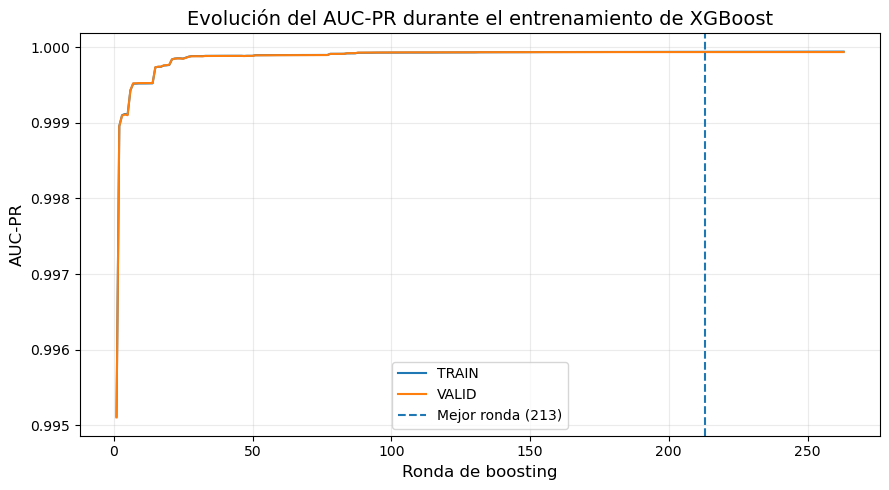

In [72]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
plt.plot(rounds, train_aucpr, label="TRAIN")
plt.plot(rounds, valid_aucpr, label="VALID")
best_round = (xgb_binary_learning_curve.best_iteration + 1)
plt.axvline(best_round, linestyle="--", label=f"Mejor ronda ({best_round})")
plt.xlabel("Ronda de boosting", fontsize=12)
plt.ylabel("AUC-PR", fontsize=12)
plt.title("Evolución del AUC-PR durante el entrenamiento de XGBoost", fontsize=14)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

La evolución similar entre entrenamiento y validación no mostró una divergencia pronunciada entre ambos conjuntos durante las rondas analizadas.

In [73]:
milestone_rounds = [1,5,10,25,50,100,best_round]
milestone_rounds = sorted(set(r for r in milestone_rounds if r <= len(train_aucpr)))
learning_curve_milestones = pd.DataFrame({
    "round": milestone_rounds,
    "train_aucpr": [train_aucpr[r - 1] for r in milestone_rounds],
    "valid_aucpr": [valid_aucpr[r - 1] for r in milestone_rounds],
})
learning_curve_milestones["gap"] = (learning_curve_milestones["train_aucpr"] - learning_curve_milestones["valid_aucpr"])
display(learning_curve_milestones.style.format({"train_aucpr": "{:.6f}", "valid_aucpr": "{:.6f}", "gap": "{:.6f}"}))

,round,train_aucpr,valid_aucpr,gap
0,1,0.995116,0.995106,0.000010
1,5,0.999109,0.999099,0.000009
2,10,0.999519,0.999524,-0.000005
3,25,0.999848,0.999845,0.000002
4,50,0.999884,0.999883,0.000001
5,100,0.999927,0.999929,-0.000002
6,213,0.999937,0.999934,0.000003


##### Importancia por gain

In [43]:
def get_xgb_feature_importance(model, feature_names, importance_type="total_gain"):
    importance_dict = (model.get_booster().get_score(importance_type=importance_type))
    rows = []
    for idx, feature_name in enumerate(feature_names):
        xgb_name = f"f{idx}"
        value = importance_dict.get(xgb_name, 0.0)
        rows.append({
            "feature": feature_name,
            importance_type: value,
        })
    result = pd.DataFrame(rows)
    total = result[importance_type].sum()
    result[f"{importance_type}_pct"] = (100 * result[importance_type] / total if total > 0 else 0)
    return (result.sort_values(importance_type, ascending=False,).reset_index(drop=True))

In [44]:
importance_total_gain = (get_xgb_feature_importance(model=xgb_binary_none, feature_names=xgb_binary_feature_names, importance_type="total_gain"))
importance_gain = (get_xgb_feature_importance(model=xgb_binary_none, feature_names=xgb_binary_feature_names, importance_type="gain"))
importance_weight = (get_xgb_feature_importance(model=xgb_binary_none, feature_names=xgb_binary_feature_names, importance_type="weight"))

In [ ]:
display(importance_total_gain.head(20).style.format({"total_gain": "{:,.2f}", "total_gain_pct": "{:.2f}%"}))

,feature,total_gain,total_gain_pct
0,frequency__sp_freq,"19,975,896.00",49.75%
1,ip_features__da_prefix_freq,"13,135,936.00",32.72%
2,ip_features__sa_prefix_freq,"1,867,662.00",4.65%
3,ip_features__sa_ip_freq,"1,159,248.88",2.89%
4,onehot__pr_ICMP,"1,025,835.06",2.55%
5,onehot__exp_6,"864,455.00",2.15%
6,frequency__dp_freq,"607,213.69",1.51%
7,num_log__ibyt,"377,359.69",0.94%
8,frequency__in_if_freq,"336,152.41",0.84%
9,ip_features__da_ip_freq,"233,981.56",0.58%


In [46]:
importance_audit = (importance_total_gain.merge(importance_gain[["feature", "gain"]], on="feature", how="left")
    .merge(importance_weight[["feature", "weight"]], on="feature", how="left")
)
importance_audit[["gain", "weight"]] = (importance_audit[["gain", "weight"]].fillna(0))
display(importance_audit.head(20).style.format({
        "total_gain": "{:,.2f}",
        "total_gain_pct": "{:.2f}%",
        "gain": "{:,.2f}",
        "weight": "{:,.0f}",
    })
)

,feature,total_gain,total_gain_pct,gain,weight
0,frequency__sp_freq,"19,975,896.00",49.75%,"15,366.07","1,300"
1,ip_features__da_prefix_freq,"13,135,936.00",32.72%,"86,420.63",152
2,ip_features__sa_prefix_freq,"1,867,662.00",4.65%,"3,543.95",527
3,ip_features__sa_ip_freq,"1,159,248.88",2.89%,"1,903.53",609
4,onehot__pr_ICMP,"1,025,835.06",2.55%,"3,799.39",270
5,onehot__exp_6,"864,455.00",2.15%,"3,694.25",234
6,frequency__dp_freq,"607,213.69",1.51%,"1,122.39",541
7,num_log__ibyt,"377,359.69",0.94%,564.07,669
8,frequency__in_if_freq,"336,152.41",0.84%,"2,710.91",124
9,ip_features__da_ip_freq,"233,981.56",0.58%,774.77,302


Se examinó la importancia acumulada de las variables mediante la ganancia producida por las divisiones de los árboles. La frecuencia del puerto de origen (sp_freq) y la frecuencia del prefijo de la dirección IP de destino (da_prefix_freq) concentraron aproximadamente el 82,5 % de la ganancia acumulada del modelo. Estos atributos son características legítimas del contexto de red, aunque sus distribuciones pueden depender parcialmente de la infraestructura específica donde se realizó la captura, de igual manera, en el análisis exploratorio realizado anteriormente ya se había evidenciado concentraciones de este tipo en las direcciones, interfaces y sistemas autónomos de algunos ataques.

##### Auditoría de firmas de tráfico

Para cada firma observada en TRAIN, ¿aparece exclusivamente en normal, exclusivamente en ataque o en ambas?

In [42]:
SIGNATURE_COLUMNS = ["pr", "sp", "dp", "tcp_flag_fin", "tcp_flag_syn", "tcp_flag_rst", "tcp_flag_psh", "tcp_flag_ack", "tcp_flag_urg", "tcp_flag_ece", "tcp_flag_cwr"]

In [47]:
SIGNATURE_LOAD_COLUMNS = (SIGNATURE_COLUMNS + ["attack_a"])
df_train_signature = load_split_dataframe(split_name="train", preprocessing_config=preprocessing_config, use_dev_sample=False, columns=SIGNATURE_LOAD_COLUMNS, project_root=PROJECT_ROOT)
df_valid_signature = load_split_dataframe(split_name="valid", preprocessing_config=preprocessing_config, use_dev_sample=False, columns=SIGNATURE_LOAD_COLUMNS, project_root=PROJECT_ROOT)
print("TRAIN firmas:", df_train_signature.shape)
print("VALID firmas:", df_valid_signature.shape)

TRAIN firmas: (15803376, 12)
VALID firmas: (3386438, 12)


In [48]:
train_signature_stats = (df_train_signature.groupby(SIGNATURE_COLUMNS, dropna=False, observed=True,)["attack_a"].agg(n_train="size", attacks_train="sum").reset_index())
train_signature_stats["normal_train"] = (train_signature_stats["n_train"] - train_signature_stats["attacks_train"])
train_signature_stats["attack_rate_train"] = (train_signature_stats["attacks_train"] / train_signature_stats["n_train"])

In [49]:
conditions = [(train_signature_stats["attacks_train"] == 0), (train_signature_stats["normal_train"] == 0)]
choices = ["pure_normal", "pure_attack"]
train_signature_stats["signature_type"] = np.select(conditions, choices, default="mixed")

In [50]:
print("Firmas únicas en TRAIN:",f"{len(train_signature_stats):,}")
display(train_signature_stats["signature_type"].value_counts().rename_axis("signature_type").reset_index(name="n_signatures"))

Firmas únicas en TRAIN: 3,364,644


,signature_type,n_signatures
0,pure_normal,3238889
1,mixed,80562
2,pure_attack,45193


In [51]:
valid_signature_eval = (df_valid_signature.merge(train_signature_stats, on=SIGNATURE_COLUMNS, how="left", validate="many_to_one"))
valid_signature_eval["seen_in_train"] = (valid_signature_eval["n_train"].notna())

In [52]:
signature_coverage = (valid_signature_eval["seen_in_train"].mean())
print("Registros VALID con firma vista en TRAIN:",f"{signature_coverage:.4%}")

Registros VALID con firma vista en TRAIN: 88.4128%


In [53]:
signature_valid_summary = (valid_signature_eval.assign(signature_type=lambda df:df["signature_type"].fillna("unseen"))
    ["signature_type"].value_counts().rename_axis("signature_type").reset_index(name="n_valid")
)
signature_valid_summary["percentage"] = (100 * signature_valid_summary["n_valid"] / len(valid_signature_eval))
display(signature_valid_summary.style.format({
        "n_valid": "{:,}",
        "percentage": "{:.4f}%",
    })
)

,signature_type,n_valid,percentage
0,pure_normal,"2,575,786",76.0618%
1,unseen,"392,395",11.5872%
2,mixed,"323,501",9.5528%
3,pure_attack,"94,756",2.7981%


In [54]:
seen_signature_valid = (valid_signature_eval[valid_signature_eval["seen_in_train"]].copy())
signature_rule_metrics = (evaluate_binary_predictions(y_true=(seen_signature_valid["attack_a"]),y_prob=(seen_signature_valid["attack_rate_train"]),threshold=0.50, experiment_name=("traffic_signature_rule")))
signature_rule_metrics_df = (pd.DataFrame([signature_rule_metrics]))
display(signature_rule_metrics_df[["precision", "recall", "f1", "PR_AUC", "ROC_AUC", "FPR", "FN", "FP"]
    ].style.format({"precision": "{:.6f}", "recall": "{:.6f}", "f1": "{:.6f}", "PR_AUC": "{:.6f}", "ROC_AUC": "{:.6f}", "FPR": "{:.6f}", "FN": "{:,.0f}", "FP": "{:,.0f}"})
)

,precision,recall,f1,PR_AUC,ROC_AUC,FPR,FN,FP
0,0.867604,0.921015,0.893512,0.922677,0.980490,0.010992,"17,154","30,524"


In [55]:
unseen_signature_valid = (valid_signature_eval[~valid_signature_eval["seen_in_train"]])
print("Firmas no vistas:", f"{len(unseen_signature_valid):,}")
if len(unseen_signature_valid) > 0:print("Proporción de ataques entre las firmas no vistas:",f"{unseen_signature_valid['attack_a'].mean():.6f}",)

Firmas no vistas: 392,395
Proporción de ataques entre las firmas no vistas: 0.008005


#### 3.1.2 Prueba de ablación de variables de infraestructura

Con el propósito de evaluar hasta qué punto el desempeño dependía de este contexto, se realizó una prueba de ablación retirando 14 características transformadas asociadas con direcciones IP y prefijos, sistemas autónomos, interfaces y exportadores. Se conservaron 35 características relacionadas principalmente con protocolo, puertos, banderas TCP, duración y volumen de los flujos.

In [ ]:
INFRASTRUCTURE_PREFIXES = ("ip_features__sa_","ip_features__da_","frequency__sas_","frequency__das_","frequency__in_if_","frequency__out_if_", "onehot__exp_")

In [ ]:
infrastructure_mask = np.array([feature.startswith(INFRASTRUCTURE_PREFIXES) for feature in xgb_binary_feature_names])
keep_behavior_mask = (~infrastructure_mask)

In [ ]:
removed_infrastructure_features = (np.asarray(xgb_binary_feature_names)[infrastructure_mask])
behavior_feature_names = (np.asarray(xgb_binary_feature_names)[keep_behavior_mask])
print("Características originales:",len(xgb_binary_feature_names))
print("Características eliminadas:",len(removed_infrastructure_features))
print("Características restantes:",len(behavior_feature_names))
print("\nVariables eliminadas:")
for feature in (removed_infrastructure_features):
    print(feature)

Características originales: 49
Características eliminadas: 14
Características restantes: 35

Variables eliminadas:
onehot__exp_1
onehot__exp_2
onehot__exp_6
onehot__exp_7
frequency__sas_freq
frequency__das_freq
frequency__in_if_freq
frequency__out_if_freq
ip_features__sa_ip_freq
ip_features__sa_prefix_freq
ip_features__sa_is_ipv6
ip_features__da_ip_freq
ip_features__da_prefix_freq
ip_features__da_is_ipv6


In [ ]:
X_train_bin_behavior = (X_train_bin_transformed[:,keep_behavior_mask])
X_valid_bin_behavior = (X_valid_bin_transformed[:,keep_behavior_mask])
print("TRAIN sin infraestructura:",X_train_bin_behavior.shape)
print("VALID sin infraestructura:", X_valid_bin_behavior.shape)

TRAIN sin infraestructura: (15803376, 35)
VALID sin infraestructura: (3386438, 35)


In [60]:
(xgb_binary_no_infrastructure, results_xgb_no_infrastructure, y_prob_valid_no_infrastructure) = run_xgb_binary_experiment(
    experiment_name=("none_no_infrastructure"),X_train=X_train_bin_behavior, y_train=y_train_bin, X_valid=X_valid_bin_behavior, y_valid=y_valid_bin,
    model_params=(XGB_BINARY_BASE_PARAMS), threshold=0.50, verbose=25,
)

Experimento: none_no_infrastructure

TRAIN:
X: (15803376, 35)
y: 15803376

VALID:
X: (3386438, 35)
y: 3386438
[0]	validation_0-aucpr:0.92709
[25]	validation_0-aucpr:0.97072
[50]	validation_0-aucpr:0.97657
[75]	validation_0-aucpr:0.97868
[100]	validation_0-aucpr:0.98035
[125]	validation_0-aucpr:0.98159
[150]	validation_0-aucpr:0.98232
[175]	validation_0-aucpr:0.98293
[200]	validation_0-aucpr:0.98412
[225]	validation_0-aucpr:0.98445
[250]	validation_0-aucpr:0.98471
[275]	validation_0-aucpr:0.98504
[300]	validation_0-aucpr:0.98514
[325]	validation_0-aucpr:0.98526
[350]	validation_0-aucpr:0.98537
[375]	validation_0-aucpr:0.98546
[400]	validation_0-aucpr:0.98555
[425]	validation_0-aucpr:0.98560
[450]	validation_0-aucpr:0.98564
[475]	validation_0-aucpr:0.98568
[500]	validation_0-aucpr:0.98571
[525]	validation_0-aucpr:0.98575
[550]	validation_0-aucpr:0.98579
[575]	validation_0-aucpr:0.98581
[600]	validation_0-aucpr:0.98584
[625]	validation_0-aucpr:0.98583
[650]	validation_0-aucpr:0.98584
[675

,experiment,threshold,n,attack_prevalence,TN,FP,FN,TP,alerts,accuracy,...,f1,specificity,FPR,FNR,ROC_AUC,PR_AUC,training_seconds,training_minutes,best_iteration,best_score
0,none_no_infrastructure,0.5,3386438,0.06506,3158737,7379,11022,209300,216679,0.994566,...,0.957893,0.997669,0.002331,0.050027,0.999183,0.985888,974.550703,16.242512,747,0.985888


In [61]:
row = results_xgb_no_infrastructure.iloc[0]
print("XGBOOST BASELINE — VALIDACIÓN")
print("-" * 45)
print(f"Precision ataque:   {row['precision']:.6f}")
print(f"Recall ataque:      {row['recall']:.6f}")
print(f"F1 ataque:          {row['f1']:.6f}")
print(f"PR-AUC:             {row['PR_AUC']:.6f}")
print(f"ROC-AUC:            {row['ROC_AUC']:.6f}")
print(f"Balanced accuracy:  {row['balanced_accuracy']:.6f}")
print()
print(f"FPR:                 {row['FPR']:.6f} ({row['FPR']:.4%})")
print(f"FNR:                 {row['FNR']:.6f} ({row['FNR']:.4%})")
print()
print(f"TN: {int(row['TN']):,}")
print(f"FP: {int(row['FP']):,}")
print(f"FN: {int(row['FN']):,}")
print(f"TP: {int(row['TP']):,}")
print()
print(f"Best iteration:      {int(row['best_iteration'])}")
print(f"Rondas utilizadas:   " f"{int(row['best_iteration']) + 1}")
print(f"Tiempo entrenamiento: "f"{row['training_minutes']:.2f} min")

XGBOOST BASELINE — VALIDACIÓN
---------------------------------------------
Precision ataque:   0.965945
Recall ataque:      0.949973
F1 ataque:          0.957893
PR-AUC:             0.985888
ROC-AUC:            0.999183
Balanced accuracy:  0.973821

FPR:                 0.002331 (0.2331%)
FNR:                 0.050027 (5.0027%)

TN: 3,158,737
FP: 7,379
FN: 11,022
TP: 209,300

Best iteration:      747
Rondas utilizadas:   748
Tiempo entrenamiento: 16.24 min


In [45]:
def evaluate_recall_by_attack(y_true, y_prob, attack_t, threshold=0.50, attack_order=None):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    attack_t = np.asarray(attack_t)
    attack_mask = (y_true == 1)
    df = pd.DataFrame({"attack_t": (attack_t[attack_mask].astype(str)),
        "score_attack": (y_prob[attack_mask]),
    })
    df["detected"] = (df["score_attack"] >= threshold).astype(np.uint8)
    results = (df.groupby("attack_t", as_index=False,).agg(
            n_attacks=("detected", "size"),
            detected=("detected", "sum"),
            mean_score=("score_attack", "mean"),
            median_score=("score_attack", "median"),
        )
    )
    results["fn"] = (results["n_attacks"] - results["detected"])
    results["recall"] = (results["detected"] / results["n_attacks"])
    if attack_order is not None:
        results["attack_t"] = (pd.Categorical(results["attack_t"], categories=attack_order, ordered=True))
        results = (results.sort_values("attack_t").reset_index(drop=True))
    macro_recall = (results["recall"].mean())
    return results, macro_recall

In [63]:
(recall_no_infrastructure, macro_recall_no_infrastructure) = evaluate_recall_by_attack(y_true=y_valid_bin, y_prob=(y_prob_valid_no_infrastructure),
    attack_t=(df_valid_labels_xgb["attack_t"]), threshold=0.50, attack_order=(ATTACK_CLASS_ORDER),
)
display(recall_no_infrastructure.style.format({"n_attacks": "{:,.0f}",
        "detected": "{:,.0f}",
        "mean_score": "{:.6f}",
        "median_score": "{:.6f}",
        "fn": "{:,.0f}",
        "recall": "{:.6f}",
    })
)
print("Macro-recall sin variables de infraestructura:",f"{macro_recall_no_infrastructure:.6f}")

,attack_t,n_attacks,detected,mean_score,median_score,fn,recall
0,icmp_f,"1,744","1,700",0.675803,0.609090,44,0.974771
1,icmp_smf,"8,922","8,768",0.980575,0.998642,154,0.982739
2,udp_f,"14,037","5,826",0.431946,0.350809,"8,211",0.415046
3,http_f,"3,444","1,179",0.434338,0.398122,"2,265",0.342334
4,tcp_w32_w,"3,644","3,644",0.998649,0.998669,0,1.000000
5,tcp_red_w,"188,355","188,154",0.980958,0.980323,201,0.998933
6,udp_reaper_w,176,29,0.426167,0.405214,147,0.164773


Macro-recall sin variables de infraestructura: 0.696942


In [64]:
comparison_ablation = pd.DataFrame({"modelo": ["XGBoost baseline","XGBoost sin infraestructura"],
    "PR_AUC": [results_xgb_binary_none.loc[0,"PR_AUC"],results_xgb_no_infrastructure.loc[0, "PR_AUC"]],
    "precision": [results_xgb_binary_none.loc[0, "precision"], results_xgb_no_infrastructure.loc[0, "precision"]],
    "recall": [results_xgb_binary_none.loc[0, "recall"], results_xgb_no_infrastructure.loc[0, "recall"]],
    "F1": [results_xgb_binary_none.loc[0,"f1"], results_xgb_no_infrastructure.loc[0, "f1"]],
    "FPR": [results_xgb_binary_none.loc[0,"FPR"], results_xgb_no_infrastructure.loc[0, "FPR"]],
    "macro_recall": [macro_recall_xgb_none, macro_recall_no_infrastructure],
})
display(comparison_ablation.style.format({
        "PR_AUC": "{:.6f}",
        "precision": "{:.6f}",
        "recall": "{:.6f}",
        "F1": "{:.6f}",
        "FPR": "{:.6f}",
        "macro_recall": "{:.6f}",
    })
)

,modelo,PR_AUC,precision,recall,F1,FPR,macro_recall
0,XGBoost baseline,0.999934,0.991013,0.997985,0.994487,0.000630,0.981614
1,XGBoost sin infraestructura,0.985888,0.965945,0.949973,0.957893,0.002331,0.696942


La eliminación de estas variables redujo el desempeño, aunque el modelo conservó valores elevados en las métricas binarias agregadas, con un F1-score de 0,9579 y un PR-AUC de 0,9859. Sin embargo, el macro-recall disminuyó de 0,9816 a 0,6969, principalmente debido a una menor detección de UDP Flood, HTTP Flood y Reaper Worm.

Estos resultados muestran que XGBoost mantiene una capacidad discriminativa elevada utilizando características más relacionadas con el comportamiento general de los flujos, pero también aprovecha el contexto de la infraestructura para mejorar la cobertura entre los diferentes tipos de ataque. Este hallazgo no evidencia una fuga directa de información, dado que las variables objetivo, auxiliares, temporales y aquellas generadas explícitamente para reconocimiento de ataques fueron excluidas previamente; sin embargo, sí debe considerarse como una limitación al extrapolar el desempeño hacia redes con una topología y distribución de tráfico diferentes.

#### 3.1.3 Prueba final de robustez

In [65]:
train_signature_index = pd.MultiIndex.from_frame(train_signature_stats[SIGNATURE_COLUMNS])
valid_signature_index = pd.MultiIndex.from_frame(df_valid_signature[SIGNATURE_COLUMNS])
seen_signature_mask = valid_signature_index.isin(train_signature_index)
unseen_signature_mask = ~seen_signature_mask
print("VALID con firma vista:",f"{seen_signature_mask.mean():.4%}")
print("VALID con firma no vista:"f"{unseen_signature_mask.mean():.4%}")

VALID con firma vista: 88.4128%
VALID con firma no vista:11.5872%


In [66]:
y_valid_np = np.asarray(y_valid_bin)
results_seen_signatures = evaluate_binary_predictions(
    y_true=y_valid_np[seen_signature_mask],
    y_prob=y_prob_valid_none[seen_signature_mask],
    threshold=0.50,
    experiment_name="xgb_seen_signatures",
)
results_unseen_signatures = evaluate_binary_predictions(
    y_true=y_valid_np[unseen_signature_mask],
    y_prob=y_prob_valid_none[unseen_signature_mask],
    threshold=0.50,
    experiment_name="xgb_unseen_signatures",
)

In [67]:
signature_robustness = pd.DataFrame([results_seen_signatures, results_unseen_signatures])
signature_robustness["subset"] = ["Firmas vistas en TRAIN", "Firmas no vistas en TRAIN"]
display(signature_robustness[["subset", "n", "attack_prevalence", "precision", "recall", "f1", "PR_AUC", "ROC_AUC", "FPR", "FN", "FP"]
    ].style.format({
        "n": "{:,.0f}",
        "attack_prevalence": "{:.4%}",
        "precision": "{:.6f}",
        "recall": "{:.6f}",
        "f1": "{:.6f}",
        "PR_AUC": "{:.6f}",
        "ROC_AUC": "{:.6f}",
        "FPR": "{:.6f}",
        "FN": "{:,.0f}",
        "FP": "{:,.0f}",
    })
)

,subset,n,attack_prevalence,precision,recall,f1,PR_AUC,ROC_AUC,FPR,FN,FP
0,Firmas vistas en TRAIN,"2,994,043",7.2538%,0.995029,0.999144,0.997082,0.999982,0.999999,0.000390,186,"1,084"
1,Firmas no vistas en TRAIN,"392,395",0.8005%,0.760084,0.917861,0.831555,0.925035,0.999363,0.002338,258,910


### 3.2 Tratamiento del desbalance

#### 3.2.1 Ponderación mediante scale_pos_weight

In [30]:
scale_pos_weight_binary = (compute_binary_scale_pos_weight(y_train_bin))
print("scale_pos_weight:",f"{scale_pos_weight_binary:.6f}")

scale_pos_weight: 14.370392


In [31]:
validate_imbalance_strategy_for_model(strategy_name="class_weight", model_family="xgboost", imbalance_config=imbalance_config)

True

In [32]:
XGB_BINARY_WEIGHT_PARAMS = (XGB_BINARY_BASE_PARAMS.copy())
XGB_BINARY_WEIGHT_PARAMS["scale_pos_weight"] = scale_pos_weight_binary

In [77]:
(xgb_binary_weight,results_xgb_binary_weight,y_prob_valid_weight) = run_xgb_binary_experiment(
    experiment_name="class_weight",
    X_train=X_train_bin_transformed,
    y_train=y_train_bin,
    X_valid=X_valid_bin_transformed,
    y_valid=y_valid_bin,
    model_params=XGB_BINARY_WEIGHT_PARAMS,
    threshold=0.50,
    verbose=25,
)

Experimento: class_weight

TRAIN:
X: (15803376, 49)
y: 15803376

VALID:
X: (3386438, 49)
y: 3386438
[0]	validation_0-aucpr:0.99703
[25]	validation_0-aucpr:0.99977
[50]	validation_0-aucpr:0.99986
[75]	validation_0-aucpr:0.99988
[100]	validation_0-aucpr:0.99990
[125]	validation_0-aucpr:0.99993
[150]	validation_0-aucpr:0.99993
[175]	validation_0-aucpr:0.99993
[200]	validation_0-aucpr:0.99993
[225]	validation_0-aucpr:0.99993
[250]	validation_0-aucpr:0.99993

Tiempo de entrenamiento: 5.55 minutos

Resultados:


,experiment,threshold,n,attack_prevalence,TN,FP,FN,TP,alerts,accuracy,...,f1,specificity,FPR,FNR,ROC_AUC,PR_AUC,training_seconds,training_minutes,best_iteration,best_score
0,class_weight,0.5,3386438,0.06506,3163292,2824,1,220321,223145,0.999166,...,0.99363,0.999108,0.000892,0.000005,0.999995,0.999934,333.182807,5.553047,200,0.999934


In [79]:
row = results_xgb_binary_weight.iloc[0]
print("XGBOOST BASELINE — VALIDACIÓN")
print("-" * 45)
print(f"Precision ataque:   {row['precision']:.6f}")
print(f"Recall ataque:      {row['recall']:.6f}")
print(f"F1 ataque:          {row['f1']:.6f}")
print(f"PR-AUC:             {row['PR_AUC']:.6f}")
print(f"ROC-AUC:            {row['ROC_AUC']:.6f}")
print(f"Balanced accuracy:  {row['balanced_accuracy']:.6f}")
print()
print(f"FPR:                 {row['FPR']:.6f} ({row['FPR']:.4%})")
print(f"FNR:                 {row['FNR']:.6f} ({row['FNR']:.4%})")
print()
print(f"TN: {int(row['TN']):,}")
print(f"FP: {int(row['FP']):,}")
print(f"FN: {int(row['FN']):,}")
print(f"TP: {int(row['TP']):,}")
print()
print(f"Best iteration:      {int(row['best_iteration'])}")
print(f"Rondas utilizadas:   " f"{int(row['best_iteration']) + 1}")
print(f"Tiempo entrenamiento: "f"{row['training_minutes']:.2f} min")

XGBOOST BASELINE — VALIDACIÓN
---------------------------------------------
Precision ataque:   0.987345
Recall ataque:      0.999995
F1 ataque:          0.993630
PR-AUC:             0.999934
ROC-AUC:            0.999995
Balanced accuracy:  0.999552

FPR:                 0.000892 (0.0892%)
FNR:                 0.000005 (0.0005%)

TN: 3,163,292
FP: 2,824
FN: 1
TP: 220,321

Best iteration:      200
Rondas utilizadas:   201
Tiempo entrenamiento: 5.55 min


In [78]:
(recall_weight, macro_recall_weight) = evaluate_recall_by_attack(y_true=y_valid_bin, y_prob=y_prob_valid_weight, attack_t=df_valid_labels_xgb["attack_t"],
    threshold=0.50, attack_order=ATTACK_CLASS_ORDER)
display(recall_weight.style.format({
        "n_attacks": "{:,.0f}",
        "detected": "{:,.0f}",
        "mean_score": "{:.6f}",
        "median_score": "{:.6f}",
        "fn": "{:,.0f}",
        "recall": "{:.6f}",
    })
)
print("Macro-recall class_weight:", f"{macro_recall_weight:.6f}")

,attack_t,n_attacks,detected,mean_score,median_score,fn,recall
0,icmp_f,"1,744","1,744",0.999822,0.999892,0,1.000000
1,icmp_smf,"8,922","8,922",0.999992,0.999994,0,1.000000
2,udp_f,"14,037","14,037",0.999955,0.999975,0,1.000000
3,http_f,"3,444","3,443",0.946056,0.946715,1,0.999710
4,tcp_w32_w,"3,644","3,644",0.999937,0.999941,0,1.000000
5,tcp_red_w,"188,355","188,355",1.000000,1.000000,0,1.000000
6,udp_reaper_w,176,176,0.999342,0.999467,0,1.000000


Macro-recall class_weight: 0.999959


#### 3.2.2 SMOTE al 15 %

In [80]:
print(imbalance_config["binary_oversampling_profiles"])

{'conservative': {'target_prevalence_approx': 0.0739, 'ratio_upper_bound': 0.5, 'max_minority_multiplier': 1.5, 'max_synthetic_samples': 150000}, 'moderate': {'target_prevalence_approx': 0.15, 'ratio_upper_bound': 0.17647058823529413, 'max_minority_multiplier': 2.54, 'max_synthetic_samples': 1585000}}


In [81]:
validate_imbalance_strategy_for_model(strategy_name="smote", model_family="xgboost", imbalance_config=imbalance_config)
smote_binary = build_resampler( strategy_name="smote", task="binary", y_train=y_train_bin, imbalance_config=imbalance_config, random_state=RANDOM_STATE,
    binary_profile="moderate",
)

In [82]:
X_train_smote, y_train_smote = (smote_binary.fit_resample(X_train_bin_transformed, y_train_bin))
print("TRAIN original:", X_train_bin_transformed.shape)
print("TRAIN después de SMOTE:", X_train_smote.shape)
display(summarize_class_distribution(y_train_smote, name="train_smote"))

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\Laura\anaconda3\envs\intro-python\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\Laura\anaconda3\envs\intro-python\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\Laura\anaconda3\envs\intro-python\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa2 in position 106: invalid start byte


TRAIN original: (15803376, 49)
TRAIN después de SMOTE: (17382595, 49)


,dataset,clase,n,porcentaje
0,train_smote,0,14775206,85.000001
1,train_smote,1,2607389,14.999999


In [83]:
XGB_BINARY_SMOTE_PARAMS = (XGB_BINARY_BASE_PARAMS.copy())
XGB_BINARY_SMOTE_PARAMS["scale_pos_weight"] = 1.0

In [84]:
(xgb_binary_smote, results_xgb_binary_smote, y_prob_valid_smote) = run_xgb_binary_experiment(
    experiment_name="smote_15",
    X_train=X_train_smote,
    y_train=y_train_smote,
    X_valid=X_valid_bin_transformed,
    y_valid=y_valid_bin,
    model_params=XGB_BINARY_SMOTE_PARAMS,
    threshold=0.50,
    verbose=25,
)

Experimento: smote_15

TRAIN:
X: (17382595, 49)
y: 17382595

VALID:
X: (3386438, 49)
y: 3386438
[0]	validation_0-aucpr:0.99891
[25]	validation_0-aucpr:0.99984
[50]	validation_0-aucpr:0.99989
[75]	validation_0-aucpr:0.99990
[100]	validation_0-aucpr:0.99993
[125]	validation_0-aucpr:0.99993
[150]	validation_0-aucpr:0.99993
[175]	validation_0-aucpr:0.99993
[200]	validation_0-aucpr:0.99993
[225]	validation_0-aucpr:0.99993
[249]	validation_0-aucpr:0.99993

Tiempo de entrenamiento: 5.62 minutos

Resultados:


,experiment,threshold,n,attack_prevalence,TN,FP,FN,TP,alerts,accuracy,...,f1,specificity,FPR,FNR,ROC_AUC,PR_AUC,training_seconds,training_minutes,best_iteration,best_score
0,smote_15,0.5,3386438,0.06506,3163579,2537,70,220252,222789,0.99923,...,0.994117,0.999199,0.000801,0.000318,0.999995,0.999934,337.292812,5.621547,199,0.999934


In [85]:
row = results_xgb_binary_smote.iloc[0]
print("XGBOOST BASELINE — VALIDACIÓN")
print("-" * 45)
print(f"Precision ataque:   {row['precision']:.6f}")
print(f"Recall ataque:      {row['recall']:.6f}")
print(f"F1 ataque:          {row['f1']:.6f}")
print(f"PR-AUC:             {row['PR_AUC']:.6f}")
print(f"ROC-AUC:            {row['ROC_AUC']:.6f}")
print(f"Balanced accuracy:  {row['balanced_accuracy']:.6f}")
print()
print(f"FPR:                 {row['FPR']:.6f} ({row['FPR']:.4%})")
print(f"FNR:                 {row['FNR']:.6f} ({row['FNR']:.4%})")
print()
print(f"TN: {int(row['TN']):,}")
print(f"FP: {int(row['FP']):,}")
print(f"FN: {int(row['FN']):,}")
print(f"TP: {int(row['TP']):,}")
print()
print(f"Best iteration:      {int(row['best_iteration'])}")
print(f"Rondas utilizadas:   " f"{int(row['best_iteration']) + 1}")
print(f"Tiempo entrenamiento: "f"{row['training_minutes']:.2f} min")

XGBOOST BASELINE — VALIDACIÓN
---------------------------------------------
Precision ataque:   0.988613
Recall ataque:      0.999682
F1 ataque:          0.994117
PR-AUC:             0.999934
ROC-AUC:            0.999995
Balanced accuracy:  0.999440

FPR:                 0.000801 (0.0801%)
FNR:                 0.000318 (0.0318%)

TN: 3,163,579
FP: 2,537
FN: 70
TP: 220,252

Best iteration:      199
Rondas utilizadas:   200
Tiempo entrenamiento: 5.62 min


In [86]:
(recall_smote, macro_recall_smote) = evaluate_recall_by_attack(y_true=y_valid_bin, y_prob=y_prob_valid_smote, attack_t=df_valid_labels_xgb["attack_t"],
    threshold=0.50, attack_order=ATTACK_CLASS_ORDER)
display(recall_smote.style.format({
        "n_attacks": "{:,.0f}",
        "detected": "{:,.0f}",
        "mean_score": "{:.6f}",
        "median_score": "{:.6f}",
        "fn": "{:,.0f}",
        "recall": "{:.6f}",
    })
)
print("Macro-recall SMOTE 15%:", f"{macro_recall_smote:.6f}")

,attack_t,n_attacks,detected,mean_score,median_score,fn,recall
0,icmp_f,"1,744","1,744",0.999451,0.999761,0,1.000000
1,icmp_smf,"8,922","8,922",0.999958,0.999957,0,1.000000
2,udp_f,"14,037","14,035",0.999782,0.999863,2,0.999858
3,http_f,"3,444","3,376",0.769054,0.762300,68,0.980256
4,tcp_w32_w,"3,644","3,644",0.999709,0.999719,0,1.000000
5,tcp_red_w,"188,355","188,355",0.999998,0.999999,0,1.000000
6,udp_reaper_w,176,176,0.998160,0.998318,0,1.000000


Macro-recall SMOTE 15%: 0.997159


#### 3.2.3 ADASYN al 15 %

In [87]:
validate_imbalance_strategy_for_model(strategy_name="adasyn", model_family="xgboost", imbalance_config=imbalance_config)
adasyn_binary = build_resampler(strategy_name="adasyn", task="binary", y_train=y_train_bin, imbalance_config=imbalance_config, random_state=RANDOM_STATE,
    binary_profile="moderate",
)

In [88]:
X_train_adasyn, y_train_adasyn = (adasyn_binary.fit_resample(X_train_bin_transformed, y_train_bin))
print("TRAIN original:", X_train_bin_transformed.shape)
print("TRAIN después de ADASYN:", X_train_adasyn.shape)
display(summarize_class_distribution(y_train_adasyn, name="train_adasyn"))

TRAIN original: (15803376, 49)
TRAIN después de ADASYN: (17379352, 49)


,dataset,clase,n,porcentaje
0,train_adasyn,0,14775206,85.015863
1,train_adasyn,1,2604146,14.984137


In [89]:
XGB_BINARY_ADASYN_PARAMS = (XGB_BINARY_BASE_PARAMS.copy())
XGB_BINARY_ADASYN_PARAMS["scale_pos_weight"] = 1.0

In [90]:
(xgb_binary_adasyn, results_xgb_binary_adasyn, y_prob_valid_adasyn) = run_xgb_binary_experiment(
    experiment_name="adasyn_15",
    X_train=X_train_adasyn,
    y_train=y_train_adasyn,
    X_valid=X_valid_bin_transformed,
    y_valid=y_valid_bin,
    model_params=XGB_BINARY_ADASYN_PARAMS,
    threshold=0.50,
    verbose=25,
)

Experimento: adasyn_15

TRAIN:
X: (17379352, 49)
y: 17379352

VALID:
X: (3386438, 49)
y: 3386438
[0]	validation_0-aucpr:0.99540
[25]	validation_0-aucpr:0.99915
[50]	validation_0-aucpr:0.99917
[75]	validation_0-aucpr:0.99977
[100]	validation_0-aucpr:0.99984
[125]	validation_0-aucpr:0.99989
[150]	validation_0-aucpr:0.99990
[175]	validation_0-aucpr:0.99991
[200]	validation_0-aucpr:0.99991
[225]	validation_0-aucpr:0.99991
[250]	validation_0-aucpr:0.99991
[275]	validation_0-aucpr:0.99991
[300]	validation_0-aucpr:0.99991
[325]	validation_0-aucpr:0.99991
[350]	validation_0-aucpr:0.99991
[375]	validation_0-aucpr:0.99991
[400]	validation_0-aucpr:0.99991
[425]	validation_0-aucpr:0.99991
[440]	validation_0-aucpr:0.99991

Tiempo de entrenamiento: 10.35 minutos

Resultados:


,experiment,threshold,n,attack_prevalence,TN,FP,FN,TP,alerts,accuracy,...,f1,specificity,FPR,FNR,ROC_AUC,PR_AUC,training_seconds,training_minutes,best_iteration,best_score
0,adasyn_15,0.5,3386438,0.06506,3163282,2834,13,220309,223143,0.999159,...,0.99358,0.999105,0.000895,0.000059,0.999994,0.999915,620.894244,10.348237,390,0.999915


In [91]:
row = results_xgb_binary_adasyn.iloc[0]
print("XGBOOST BASELINE — VALIDACIÓN")
print("-" * 45)
print(f"Precision ataque:   {row['precision']:.6f}")
print(f"Recall ataque:      {row['recall']:.6f}")
print(f"F1 ataque:          {row['f1']:.6f}")
print(f"PR-AUC:             {row['PR_AUC']:.6f}")
print(f"ROC-AUC:            {row['ROC_AUC']:.6f}")
print(f"Balanced accuracy:  {row['balanced_accuracy']:.6f}")
print()
print(f"FPR:                 {row['FPR']:.6f} ({row['FPR']:.4%})")
print(f"FNR:                 {row['FNR']:.6f} ({row['FNR']:.4%})")
print()
print(f"TN: {int(row['TN']):,}")
print(f"FP: {int(row['FP']):,}")
print(f"FN: {int(row['FN']):,}")
print(f"TP: {int(row['TP']):,}")
print()
print(f"Best iteration:      {int(row['best_iteration'])}")
print(f"Rondas utilizadas:   " f"{int(row['best_iteration']) + 1}")
print(f"Tiempo entrenamiento: "f"{row['training_minutes']:.2f} min")

XGBOOST BASELINE — VALIDACIÓN
---------------------------------------------
Precision ataque:   0.987300
Recall ataque:      0.999941
F1 ataque:          0.993580
PR-AUC:             0.999915
ROC-AUC:            0.999994
Balanced accuracy:  0.999523

FPR:                 0.000895 (0.0895%)
FNR:                 0.000059 (0.0059%)

TN: 3,163,282
FP: 2,834
FN: 13
TP: 220,309

Best iteration:      390
Rondas utilizadas:   391
Tiempo entrenamiento: 10.35 min


In [92]:
(recall_adasyn, macro_recall_adasyn) = evaluate_recall_by_attack(y_true=y_valid_bin, y_prob=y_prob_valid_adasyn, attack_t=df_valid_labels_xgb["attack_t"],
    threshold=0.50, attack_order=ATTACK_CLASS_ORDER)
display(recall_adasyn.style.format({
        "n_attacks": "{:,.0f}",
        "detected": "{:,.0f}",
        "mean_score": "{:.6f}",
        "median_score": "{:.6f}",
        "fn": "{:,.0f}",
        "recall": "{:.6f}",
    })
)
print("Macro-recall ADASYN 15%:", f"{macro_recall_adasyn:.6f}")

,attack_t,n_attacks,detected,mean_score,median_score,fn,recall
0,icmp_f,"1,744","1,744",0.999848,0.999958,0,1.000000
1,icmp_smf,"8,922","8,922",0.999991,0.999992,0,1.000000
2,udp_f,"14,037","14,037",0.999981,0.999990,0,1.000000
3,http_f,"3,444","3,431",0.921416,0.984669,13,0.996225
4,tcp_w32_w,"3,644","3,644",0.999979,0.999977,0,1.000000
5,tcp_red_w,"188,355","188,355",0.999999,0.999998,0,1.000000
6,udp_reaper_w,176,176,0.999952,0.999968,0,1.000000


Macro-recall ADASYN 15%: 0.999461


#### 3.2.4 Comparación de los cuatro escenarios

In [93]:
results_imbalance_binary = pd.concat([results_xgb_binary_none, results_xgb_binary_weight,results_xgb_binary_smote,results_xgb_binary_adasyn], ignore_index=True)

In [94]:
macro_recall_map = {
    "none": macro_recall_xgb_none,
    "class_weight": macro_recall_weight,
    "smote_15": macro_recall_smote,
    "adasyn_15": macro_recall_adasyn,
}
results_imbalance_binary["macro_recall"] = (results_imbalance_binary["experiment"].map(macro_recall_map))

In [95]:
comparison_columns = ["experiment", "precision", "recall", "f1", "PR_AUC", "ROC_AUC", "balanced_accuracy", "FPR", "FN", "FP", "macro_recall", "best_iteration", "training_minutes"]
display(results_imbalance_binary[comparison_columns].style.format({
        "precision": "{:.6f}",
        "recall": "{:.6f}",
        "f1": "{:.6f}",
        "PR_AUC": "{:.6f}",
        "ROC_AUC": "{:.6f}",
        "balanced_accuracy": "{:.6f}",
        "FPR": "{:.6f}",
        "FN": "{:,.0f}",
        "FP": "{:,.0f}",
        "macro_recall": "{:.6f}",
        "best_iteration": "{:,.0f}",
        "training_minutes": "{:.2f}",
    })
)

,experiment,precision,recall,f1,PR_AUC,ROC_AUC,balanced_accuracy,FPR,FN,FP,macro_recall,best_iteration,training_minutes
0,none,0.991013,0.997985,0.994487,0.999934,0.999995,0.998677,0.000630,444,"1,994",0.981614,212,5.91
1,class_weight,0.987345,0.999995,0.993630,0.999934,0.999995,0.999552,0.000892,1,"2,824",0.999959,200,5.55
2,smote_15,0.988613,0.999682,0.994117,0.999934,0.999995,0.999440,0.000801,70,"2,537",0.997159,199,5.62
3,adasyn_15,0.987300,0.999941,0.993580,0.999915,0.999994,0.999523,0.000895,13,"2,834",0.999461,390,10.35


In [97]:
recall_xgb_none = (xgb_valid_attack_results.copy())

In [98]:
recall_comparison = pd.DataFrame({
    "attack_t": ATTACK_CLASS_ORDER,
    "none": (recall_xgb_none.set_index("attack_t").loc[ATTACK_CLASS_ORDER, "recall"].to_numpy()),
    "class_weight": (recall_weight.set_index("attack_t").loc[ATTACK_CLASS_ORDER, "recall"].to_numpy()),
    "smote_15": (recall_smote.set_index("attack_t").loc[ATTACK_CLASS_ORDER, "recall"].to_numpy()),
    "adasyn_15": (recall_adasyn.set_index("attack_t").loc[ATTACK_CLASS_ORDER, "recall"].to_numpy()),
})
display(recall_comparison.style.format({"none": "{:.6f}", "class_weight": "{:.6f}", "smote_15": "{:.6f}", "adasyn_15": "{:.6f}"}))

,attack_t,none,class_weight,smote_15,adasyn_15
0,icmp_f,1.000000,1.000000,1.000000,1.000000
1,icmp_smf,1.000000,1.000000,1.000000,1.000000
2,udp_f,0.999929,1.000000,0.999858,1.000000
3,http_f,0.871370,0.999710,0.980256,0.996225
4,tcp_w32_w,1.000000,1.000000,1.000000,1.000000
5,tcp_red_w,1.000000,1.000000,1.000000,1.000000
6,udp_reaper_w,1.000000,1.000000,1.000000,1.000000


In [ ]:
XGB_IMBALANCE_RESULTS_PATH = (XGB_BINARY_RESULTS_PATH / "imbalance_experiments")
XGB_IMBALANCE_RESULTS_PATH.mkdir(parents=True, exist_ok=True)
results_imbalance_binary.to_csv(XGB_IMBALANCE_RESULTS_PATH / "xgb_binary_imbalance_results.csv", index=False)
recall_comparison.to_csv(XGB_IMBALANCE_RESULTS_PATH / "xgb_binary_recall_by_attack.csv", index=False)

In [102]:
# Probabilidades de VALID
np.savez_compressed(XGB_IMBALANCE_RESULTS_PATH / "xgb_binary_valid_probabilities.npz",y_valid=np.asarray(y_valid_bin, dtype=np.uint8),
    none=np.asarray(y_prob_valid_none, dtype=np.float32), class_weight=np.asarray(y_prob_valid_weight, dtype=np.float32),
    smote_15=np.asarray(y_prob_valid_smote, dtype=np.float32), adasyn_15=np.asarray(y_prob_valid_adasyn, dtype=np.float32)
)

In [103]:
xgb_binary_none.save_model(XGB_MODELS_PATH / "xgb_binary_baseline_none.json")
xgb_binary_weight.save_model(XGB_MODELS_PATH / "xgb_binary_class_weight.json")
joblib.dump(xgb_binary_preprocessor, XGB_MODELS_PATH / "xgb_binary_preprocessor.joblib")
with open(XGB_IMBALANCE_RESULTS_PATH / "xgb_binary_base_params.json","w", encoding="utf-8") as file: json.dump(XGB_BINARY_BASE_PARAMS, file, indent=4)

### 3.3 Optimización de hiperparámetros

Se seleccionó la ponderación de la clase positiva mediante `scale_pos_weight` como escenario final para la optimización de XGBoost. Debido al tamaño del conjunto completo de entrenamiento, la búsqueda se realiza sobre una muestra estratificada de 1.500.000 registros extraída exclusivamente de TRAIN, conservando la proporción original de las clases. Se emplea validación cruzada estratificada de tres particiones.

El preprocesamiento se ajusta de forma independiente dentro de cada fold, utilizando exclusivamente la partición de entrenamiento correspondiente, de esta
manera, las medianas, frecuencias, categorías y demás transformaciones no utilizan información del fold empleado como validación interna.

In [33]:
from sklearn.model_selection import (StratifiedShuffleSplit, StratifiedKFold, ParameterGrid)
import os
import time
import json
import gc

In [28]:
XGB_HYPERPARAM_RESULTS_PATH = (XGB_BINARY_RESULTS_PATH / "hyperparameter_search" / "class_weight")
XGB_HYPERPARAM_RESULTS_PATH.mkdir(parents=True, exist_ok=True)
print("Resultados de búsqueda:", XGB_HYPERPARAM_RESULTS_PATH)

Resultados de búsqueda: C:\Users\Laura\Documents\TrabajoGrado2026\TG2026\results\modeling\xgboost\binary\hyperparameter_search\class_weight


In [34]:
TUNING_SAMPLE_SIZE = 1_500_000
df_train_tuning_source = load_split_dataframe(split_name="train", preprocessing_config=preprocessing_config, use_dev_sample=False, columns=FULL_BINARY_COLUMNS, project_root=PROJECT_ROOT)
print("TRAIN disponible:", df_train_tuning_source.shape)

TRAIN disponible: (15803376, 23)


In [35]:
sss_tuning = StratifiedShuffleSplit(n_splits=1, train_size=TUNING_SAMPLE_SIZE, random_state=RANDOM_STATE)
y_tuning_source = (df_train_tuning_source["attack_a"])
tuning_idx, _ = next(sss_tuning.split(y_tuning_source, y_tuning_source))
X_train_tuning_raw = (df_train_tuning_source.iloc[tuning_idx][predictor_columns].reset_index(drop=True))
y_train_tuning = (df_train_tuning_source.iloc[tuning_idx]["attack_a"].reset_index(drop=True))
print("TUNING X:", X_train_tuning_raw.shape)
print("TUNING y:", y_train_tuning.shape)
display(summarize_class_distribution(y_train_tuning, name="tuning"))

TUNING X: (1500000, 22)
TUNING y: (1500000,)


,dataset,clase,n,porcentaje
0,tuning,0,1402410,93.494
1,tuning,1,97590,6.506


In [31]:
np.save(XGB_HYPERPARAM_RESULTS_PATH / "tuning_indices.npy", tuning_idx)

In [32]:
del df_train_tuning_source
del y_tuning_source
del tuning_idx
gc.collect()

117

#### 3.3.1 Diseño de la Grid Search

Grid Search exhaustiva por etapas.

- 1 Etapa: Se buscan parámetros que más directamente controlan la estructura y aprendizaje de los árboles -> max_depth, min_child_weight y learning_rate.

In [33]:
XGB_GRID_STAGE_1 = {"max_depth": [4, 6, 8], "min_child_weight": [1, 5, 10], "learning_rate": [0.05, 0.10]}

In [34]:
xgb_stage1_candidates = list(ParameterGrid(XGB_GRID_STAGE_1))
print("Configuraciones:", len(xgb_stage1_candidates))
print("Entrenamientos totales:", len(xgb_stage1_candidates) * 3)

Configuraciones: 18
Entrenamientos totales: 54


Parámetros fijos durante esta etapa

In [35]:
XGB_TUNING_FIXED_PARAMS = (XGB_BINARY_BASE_PARAMS.copy())
XGB_TUNING_FIXED_PARAMS.update({
    "n_estimators": 1500,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "gamma": 0.0,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "tree_method": "hist",
    "eval_metric": "aucpr",
    "early_stopping_rounds": 50,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
})

#### 3.3.2 Validación cruzada con preprocesamiento por fold

In [36]:
cv_xgb_tuning = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [37]:
def run_xgb_grid_search_stage(stage_name, candidates, X_tuning_raw, y_tuning, fixed_params, results_path):
    """
    Grid Search manual para XGBoost.
    - StratifiedKFold de 3 particiones.
    - Preprocesamiento ajustado exclusivamente con el TRAIN interno de cada fold.
    - scale_pos_weight calculado dentro de cada fold.
    - PR-AUC como métrica principal.
    - Checkpoint después de cada candidato/fold.
    """
    stage_path = (results_path / stage_name)
    stage_path.mkdir(parents=True, exist_ok=True)
    checkpoint_path = (stage_path / "checkpoint_folds.csv")
    temp_path = (stage_path / "checkpoint_folds_tmp.csv")
    if checkpoint_path.exists():
        df_checkpoint = pd.read_csv(checkpoint_path)
        print("Checkpoint encontrado:", len(df_checkpoint), "evaluaciones guardadas.")
    else:
        df_checkpoint = pd.DataFrame()
        print("Búsqueda iniciada desde cero.")

    folds = list(cv_xgb_tuning.split(X_tuning_raw, y_tuning))
    for fold_id, (train_idx, valid_idx) in enumerate(folds):
        print("\n")
        print("=" * 75)
        print(f"FOLD {fold_id + 1}/3")
        print("=" * 75)
        X_fold_train_raw = (X_tuning_raw.iloc[train_idx])
        y_fold_train = (y_tuning.iloc[train_idx])
        X_fold_valid_raw = (X_tuning_raw.iloc[valid_idx])
        y_fold_valid = (y_tuning.iloc[valid_idx])
        print("TRAIN interno:", X_fold_train_raw.shape)
        print("VALID interno:", X_fold_valid_raw.shape)
     
        # Preprocesamiento aprendido exclusivamente en el fold
        fold_preprocessor = (build_base_preprocessor(preprocessing_config=(preprocessing_config), model_family="xgboost"))
        start_preprocessing = (time.perf_counter())
        X_fold_train = (fold_preprocessor.fit_transform(X_fold_train_raw))
        X_fold_valid = (fold_preprocessor.transform(X_fold_valid_raw))
        preprocessing_time = (time.perf_counter() - start_preprocessing)
        print("Características transformadas:", X_fold_train.shape[1])
        print("Tiempo preprocesamiento:", f"{preprocessing_time / 60:.2f} min")
  
        # Peso calculado solamente con entrenamiento del fold
        fold_scale_pos_weight = (compute_binary_scale_pos_weight(y_fold_train))
        print("scale_pos_weight fold:", f"{fold_scale_pos_weight:.6f}")

        # Evaluación de candidatos
        for candidate_id, candidate in enumerate(candidates):
            candidate_key = json.dumps(candidate, sort_keys=True)
            if not df_checkpoint.empty:
                already_done = ((df_checkpoint["candidate_key"] == candidate_key) & (df_checkpoint["fold"] == fold_id)).any()
                if already_done:
                    print(f"Candidato " f"{candidate_id + 1}/"f"{len(candidates)} " f"ya guardado → omitido.")
                    continue

            print("\n" + "-" * 65)
            print( f"Candidato "f"{candidate_id + 1}/"f"{len(candidates)}")
            print(candidate)
            model_params = (fixed_params.copy())
            model_params.update(candidate)
            model_params["scale_pos_weight"] = fold_scale_pos_weight
            model = XGBClassifier(**model_params)
            start_time = (time.perf_counter())
            model.fit(X_fold_train, y_fold_train, eval_set=[(X_fold_valid, y_fold_valid)], verbose=False)
            fit_time = (time.perf_counter() - start_time)
            y_prob = (model.predict_proba(X_fold_valid)[:, 1])
            metrics = (evaluate_binary_predictions(y_true=y_fold_valid, y_prob=y_prob, threshold=0.50, experiment_name=(f"{stage_name}_" f"{candidate_id}_" f"fold_{fold_id}")))
            result = {
                "stage": stage_name, "candidate_id": candidate_id, "candidate_key": candidate_key, "fold": fold_id,
                "max_depth": candidate.get("max_depth"), "min_child_weight":candidate.get("min_child_weight"),
                "learning_rate": candidate.get("learning_rate"), "subsample": candidate.get("subsample", fixed_params.get("subsample")),
                "colsample_bytree": candidate.get("colsample_bytree", fixed_params.get("colsample_bytree")), "gamma": candidate.get("gamma", fixed_params.get("gamma")),
                "reg_alpha": candidate.get("reg_alpha", fixed_params.get("reg_alpha")), "reg_lambda": candidate.get("reg_lambda", fixed_params.get("reg_lambda")),
                "scale_pos_weight": fold_scale_pos_weight, "pr_auc": metrics["PR_AUC"], "roc_auc": metrics["ROC_AUC"], "precision_050": metrics["precision"],
                "recall_050": metrics["recall"], "f1_050": metrics["f1"], "balanced_accuracy_050": metrics["balanced_accuracy"], "fpr_050": metrics["FPR"],
                "fn_050": metrics["FN"], "fp_050": metrics["FP"], "best_iteration": int(model.best_iteration), "best_score": float(model.best_score),
                "fit_time_seconds": fit_time, "n_features": X_fold_train.shape[1],
            }
            df_checkpoint = pd.concat([df_checkpoint, pd.DataFrame([result])], ignore_index=True)
            df_checkpoint.to_csv(temp_path, index=False, encoding="utf-8-sig")
            os.replace(temp_path, checkpoint_path)
            print(f"PR-AUC: " f"{metrics['PR_AUC']:.6f}")
            print(f"F1 @ 0.50: " f"{metrics['f1']:.6f}")
            print(f"Recall @ 0.50: " f"{metrics['recall']:.6f}")
            print(f"FPR @ 0.50: " f"{metrics['FPR']:.6f}")
            print(f"Best iteration: " f"{model.best_iteration}")
            print(f"Tiempo: " f"{fit_time / 60:.2f} min")
            print("Checkpoint guardado.")
            del model
            del y_prob
            gc.collect()
        # Liberar matrices del fold
        del fold_preprocessor
        del X_fold_train
        del X_fold_valid
        del X_fold_train_raw
        del X_fold_valid_raw
        del y_fold_train
        del y_fold_valid
        gc.collect()

    return df_checkpoint

La función usa scale_pos_weight calculado de manera independiente en cada fold, en vez de fijar directamente el 14,370392 obtenido del entrenamiento completo. El principio es el mismo que implementa compute_binary_scale_pos_weight: negativos/positivos.

In [38]:
def summarize_xgb_grid_search(df_search):
    return (df_search.groupby(["candidate_id", "max_depth", "min_child_weight", "learning_rate", "subsample", "colsample_bytree", "gamma", "reg_alpha", "reg_lambda"],
            as_index=False).agg(mean_pr_auc=("pr_auc", "mean"),std_pr_auc=("pr_auc", "std"), mean_roc_auc=("roc_auc", "mean"),
            mean_precision_050=("precision_050", "mean"), mean_recall_050=("recall_050", "mean"), mean_f1_050=("f1_050", "mean"),
            mean_balanced_accuracy_050=("balanced_accuracy_050", "mean"), mean_fpr_050=("fpr_050", "mean"), mean_fn_050=("fn_050", "mean"),
            mean_fp_050=("fp_050", "mean"), mean_best_iteration=("best_iteration", "mean"), std_best_iteration=("best_iteration", "std"),
            mean_fit_time_min=("fit_time_seconds", lambda x: x.mean() / 60),
            completed_folds=("fold", "count")).sort_values(["mean_pr_auc", "std_pr_auc"], ascending=[False, True]).reset_index(drop=True)
    )

#### 3.3.3 Ejecutar la primera malla

In [39]:
df_xgb_stage1_search = (run_xgb_grid_search_stage(stage_name="stage_1_structure",
        candidates=xgb_stage1_candidates,
        X_tuning_raw=X_train_tuning_raw,
        y_tuning=y_train_tuning,
        fixed_params=XGB_TUNING_FIXED_PARAMS,
        results_path=(XGB_HYPERPARAM_RESULTS_PATH),
    )
)

Búsqueda iniciada desde cero.


FOLD 1/3
TRAIN interno: (1000000, 22)
VALID interno: (500000, 22)
Características transformadas: 49
Tiempo preprocesamiento: 0.57 min
scale_pos_weight fold: 14.370427

-----------------------------------------------------------------
Candidato 1/18
{'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 1}
PR-AUC: 0.999932
F1 @ 0.50: 0.993996
Recall @ 0.50: 1.000000
FPR @ 0.50: 0.000841
Best iteration: 490
Tiempo: 1.34 min
Checkpoint guardado.

-----------------------------------------------------------------
Candidato 2/18
{'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 5}
PR-AUC: 0.999927
F1 @ 0.50: 0.993996
Recall @ 0.50: 1.000000
FPR @ 0.50: 0.000841
Best iteration: 418
Tiempo: 1.15 min
Checkpoint guardado.

-----------------------------------------------------------------
Candidato 3/18
{'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 10}
PR-AUC: 0.999926
F1 @ 0.50: 0.993874
Recall @ 0.50: 1.000000
FPR @ 0.50: 0.000858
Bes

In [40]:
df_xgb_stage1_summary = (summarize_xgb_grid_search(df_xgb_stage1_search))

In [41]:
STAGE1_PATH = (XGB_HYPERPARAM_RESULTS_PATH / "stage_1_structure")
df_xgb_stage1_summary.to_csv(STAGE1_PATH / "candidate_summary.csv", index=False, encoding="utf-8-sig")

In [42]:
display(df_xgb_stage1_summary.head(10).style.format({"mean_pr_auc": "{:.8f}", "std_pr_auc": "{:.8f}", "mean_roc_auc": "{:.8f}", "mean_precision_050": "{:.6f}",
        "mean_recall_050": "{:.6f}", "mean_f1_050": "{:.6f}", "mean_balanced_accuracy_050": "{:.6f}", "mean_fpr_050": "{:.6f}", "mean_fn_050": "{:.2f}",
        "mean_fp_050": "{:.2f}", "mean_best_iteration": "{:.2f}", "std_best_iteration": "{:.2f}", "mean_fit_time_min": "{:.2f}"})
)

,candidate_id,max_depth,min_child_weight,learning_rate,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_precision_050,mean_recall_050,mean_f1_050,mean_balanced_accuracy_050,mean_fpr_050,mean_fn_050,mean_fp_050,mean_best_iteration,std_best_iteration,mean_fit_time_min,completed_folds
0,10,4,5,0.100000,1.000000,1.000000,0.000000,0.000000,1.000000,0.99992517,0.00000623,0.99999478,0.987314,0.999990,0.993611,0.999548,0.000894,0.33,418.00,356.33,62.68,1.04,3
1,13,6,5,0.100000,1.000000,1.000000,0.000000,0.000000,1.000000,0.99992502,0.00000465,0.99999477,0.987264,0.999969,0.993576,0.999536,0.000898,1.00,419.67,180.67,79.56,0.60,3
2,16,8,5,0.100000,1.000000,1.000000,0.000000,0.000000,1.000000,0.99992423,0.00000546,0.99999471,0.987264,0.999990,0.993586,0.999546,0.000898,0.33,419.67,153.67,23.80,0.52,3
3,0,4,1,0.050000,1.000000,1.000000,0.000000,0.000000,1.000000,0.99992392,0.00000812,0.99999469,0.987294,0.999990,0.993601,0.999547,0.000896,0.33,418.67,548.33,82.72,1.49,3
4,7,8,5,0.050000,1.000000,1.000000,0.000000,0.000000,1.000000,0.99992366,0.00000290,0.99999467,0.987363,0.999939,0.993611,0.999524,0.000891,2.00,416.33,340.00,222.52,1.00,3
5,4,6,5,0.050000,1.000000,1.000000,0.000000,0.000000,1.000000,0.99992359,0.00000433,0.99999467,0.987343,0.999959,0.993611,0.999533,0.000892,1.33,417.00,419.33,188.51,1.22,3
6,14,6,10,0.100000,1.000000,1.000000,0.000000,0.000000,1.000000,0.99992357,0.00000575,0.99999466,0.987293,0.999939,0.993575,0.999521,0.000896,2.00,418.67,289.33,125.03,0.90,3
7,9,4,1,0.100000,1.000000,1.000000,0.000000,0.000000,1.000000,0.99992349,0.00000786,0.99999466,0.987384,0.999949,0.993626,0.999530,0.000889,1.67,415.67,345.00,98.66,1.01,3
8,17,8,10,0.100000,1.000000,1.000000,0.000000,0.000000,1.000000,0.99992324,0.00000576,0.99999464,0.987244,0.999969,0.993566,0.999535,0.000899,1.00,420.33,165.67,37.10,0.56,3
9,6,8,1,0.050000,1.000000,1.000000,0.000000,0.000000,1.000000,0.99992237,0.00000700,0.99999458,0.987284,0.999980,0.993591,0.999542,0.000896,0.67,419.00,253.33,9.45,0.73,3


Comparar con la configuración inicial

In [43]:
baseline_stage1_mask = ((df_xgb_stage1_summary["max_depth"] == 6) & (df_xgb_stage1_summary["min_child_weight"] == 1) & (df_xgb_stage1_summary["learning_rate"] == 0.10))
baseline_stage1_result = (df_xgb_stage1_summary[baseline_stage1_mask])
best_stage1_result = (df_xgb_stage1_summary.head(1))
print("Mejor candidato:")
display(best_stage1_result)
print("\nConfiguración inicial:")
display(baseline_stage1_result)

Mejor candidato:


,candidate_id,max_depth,min_child_weight,learning_rate,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,mean_pr_auc,...,mean_recall_050,mean_f1_050,mean_balanced_accuracy_050,mean_fpr_050,mean_fn_050,mean_fp_050,mean_best_iteration,std_best_iteration,mean_fit_time_min,completed_folds
0,10,4,5,0.1,1.0,1.0,0.0,0.0,1.0,0.999925,...,0.99999,0.993611,0.999548,0.000894,0.333333,418.0,356.333333,62.684395,1.04354,3



Configuración inicial:


,candidate_id,max_depth,min_child_weight,learning_rate,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,mean_pr_auc,...,mean_recall_050,mean_f1_050,mean_balanced_accuracy_050,mean_fpr_050,mean_fn_050,mean_fp_050,mean_best_iteration,std_best_iteration,mean_fit_time_min,completed_folds
13,12,6,1,0.1,1.0,1.0,0.0,0.0,1.0,0.999921,...,0.999775,0.993701,0.999454,0.000866,7.333333,405.0,219.0,55.560778,0.705127,3


El mejor PR-AUC aparece con árboles menos profundos y divisiones más conservadoras, lo que introduce más regularización estructural.

In [44]:
# Guardar el ganador provisional
best_stage1 = (df_xgb_stage1_summary.iloc[0])
BEST_STAGE1_PARAMS = {"max_depth": int(best_stage1["max_depth"]), "min_child_weight": float(best_stage1["min_child_weight"]), "learning_rate": float(best_stage1["learning_rate"])}
with open(STAGE1_PATH / "best_stage1_params.json", "w", encoding="utf-8") as file: json.dump(BEST_STAGE1_PARAMS, file, indent=4)
print("Mejor configuración provisional:")
print(BEST_STAGE1_PARAMS)

Mejor configuración provisional:
{'max_depth': 4, 'min_child_weight': 5.0, 'learning_rate': 0.1}


Las configuraciones evaluadas presentaron un desempeño muy similar y cercano al máximo. La combinación max_depth=4, min_child_weight=5 y learning_rate=0,10 obtuvo el mayor PR-AUC promedio, aunque las diferencias respecto de la configuración inicial fueron reducidas.

In [45]:
# (4,5,0.10) gana en PR-AUC y recall, mientras que (6,1,0.10) tiene F1 y FPR ligeramente mejores.
STAGE1_FINALISTS = [{"max_depth": 4, "min_child_weight": 5, "learning_rate": 0.10}, {"max_depth": 6, "min_child_weight": 1, "learning_rate": 0.10}]

#### 3.3.4 Ejecutar la segunda malla

(muestreo de observaciones y características) - subsample: [0.8, 0.9, 1.0] - colsample_bytree: [0.8, 0.9, 1.0]

2 estructuras finalistas × 3 × 3
= 18 configuraciones

× 3 folds
= 54 entrenamientos

In [46]:
from sklearn.model_selection import ParameterGrid
SAMPLING_GRID = {"subsample": [0.8, 0.9, 1.0], "colsample_bytree": [0.8, 0.9, 1.0]}

In [47]:
xgb_stage2_candidates = []
for structure in STAGE1_FINALISTS:
    for sampling_params in ParameterGrid(SAMPLING_GRID):
        candidate = {**structure, **sampling_params}
        xgb_stage2_candidates.append(candidate)

print("Configuraciones Stage 2:", len(xgb_stage2_candidates))
print("Entrenamientos totales:", len(xgb_stage2_candidates) * 3)

Configuraciones Stage 2: 18
Entrenamientos totales: 54


Todos los demás parámetros quedan: 
- gamma = 0
- reg_alpha = 0
- reg_lambda = 1
- scale_pos_weight ≈ 14.37 por fold
- tree_method = hist
- early stopping = 50

In [48]:
df_xgb_stage2_search = (run_xgb_grid_search_stage(stage_name="stage_2_sampling",
        candidates=xgb_stage2_candidates,
        X_tuning_raw=X_train_tuning_raw,
        y_tuning=y_train_tuning,
        fixed_params=XGB_TUNING_FIXED_PARAMS,
        results_path=XGB_HYPERPARAM_RESULTS_PATH,
    )
)

Búsqueda iniciada desde cero.


FOLD 1/3
TRAIN interno: (1000000, 22)
VALID interno: (500000, 22)
Características transformadas: 49
Tiempo preprocesamiento: 0.60 min
scale_pos_weight fold: 14.370427

-----------------------------------------------------------------
Candidato 1/18
{'max_depth': 4, 'min_child_weight': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8, 'subsample': 0.8}
PR-AUC: 0.999931
F1 @ 0.50: 0.993980
Recall @ 0.50: 0.999969
FPR @ 0.50: 0.000841
Best iteration: 320
Tiempo: 1.04 min
Checkpoint guardado.

-----------------------------------------------------------------
Candidato 2/18
{'max_depth': 4, 'min_child_weight': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8, 'subsample': 0.9}
PR-AUC: 0.999931
F1 @ 0.50: 0.993996
Recall @ 0.50: 1.000000
FPR @ 0.50: 0.000841
Best iteration: 250
Tiempo: 0.82 min
Checkpoint guardado.

-----------------------------------------------------------------
Candidato 3/18
{'max_depth': 4, 'min_child_weight': 5, 'learning_rate': 0.1, 'co

In [49]:
df_xgb_stage2_summary = (summarize_xgb_grid_search(df_xgb_stage2_search))
display(df_xgb_stage2_summary.head(10).style.format({
        "mean_pr_auc": "{:.8f}", "std_pr_auc": "{:.8f}", "mean_precision_050": "{:.6f}", "mean_recall_050": "{:.6f}", "mean_f1_050": "{:.6f}", "mean_fpr_050": "{:.6f}",
        "mean_fn_050": "{:.2f}", "mean_fp_050": "{:.2f}", "mean_best_iteration": "{:.2f}", "mean_fit_time_min": "{:.2f}"})
)

,candidate_id,max_depth,min_child_weight,learning_rate,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_precision_050,mean_recall_050,mean_f1_050,mean_balanced_accuracy_050,mean_fpr_050,mean_fn_050,mean_fp_050,mean_best_iteration,std_best_iteration,mean_fit_time_min,completed_folds
0,4,4,5,0.100000,0.900000,0.900000,0.000000,0.000000,1.000000,0.99992520,0.00000777,0.999995,0.987364,0.999969,0.993626,0.999539,0.000891,1.00,416.33,337.33,9.712535,1.08,3
1,8,4,5,0.100000,1.000000,1.000000,0.000000,0.000000,1.000000,0.99992517,0.00000623,0.999995,0.987314,0.999990,0.993611,0.999548,0.000894,0.33,418.00,356.33,62.684395,1.04,3
2,5,4,5,0.100000,1.000000,0.900000,0.000000,0.000000,1.000000,0.99992512,0.00000748,0.999995,0.987364,0.999990,0.993637,0.999550,0.000891,0.33,416.33,409.67,61.174613,1.21,3
3,2,4,5,0.100000,1.000000,0.800000,0.000000,0.000000,1.000000,0.99992502,0.00000460,0.999995,0.987284,0.999990,0.993596,0.999547,0.000896,0.33,419.00,347.00,95.535334,1.03,3
4,1,4,5,0.100000,0.900000,0.800000,0.000000,0.000000,1.000000,0.99992456,0.00000716,0.999995,0.987324,0.999980,0.993611,0.999543,0.000893,0.67,417.67,316.67,58.594653,1.01,3
5,7,4,5,0.100000,0.900000,1.000000,0.000000,0.000000,1.000000,0.99992448,0.00000744,0.999995,0.987234,0.999980,0.993566,0.999540,0.000900,0.67,420.67,279.67,38.991452,0.89,3
6,3,4,5,0.100000,0.800000,0.900000,0.000000,0.000000,1.000000,0.99992405,0.00000689,0.999995,0.987224,0.999969,0.993555,0.999534,0.000901,1.00,421.00,246.00,69.548544,0.81,3
7,10,6,1,0.100000,0.900000,0.800000,0.000000,0.000000,1.000000,0.99992362,0.00000714,0.999995,0.987524,0.999939,0.993692,0.999530,0.000879,2.00,411.00,169.00,27.874720,0.63,3
8,11,6,1,0.100000,1.000000,0.800000,0.000000,0.000000,1.000000,0.99992359,0.00000645,0.999995,0.987453,0.999939,0.993656,0.999527,0.000884,2.00,413.33,186.00,49.789557,0.64,3
9,0,4,5,0.100000,0.800000,0.800000,0.000000,0.000000,1.000000,0.99992346,0.00000776,0.999995,0.987264,0.999980,0.993581,0.999541,0.000898,0.67,419.67,286.67,29.143324,0.93,3


`subsample` y `colsample_bytree` prácticamente no cambian la capacidad discriminativa del modelo.

#### 3.3.5 Ejecutar la tercera malla

Regularización -> gamma, reg_alpha, reg_lambda

2 × 2 × 3 = 12 configuraciones
× 3 folds = 36 entrenamientos

In [50]:
XGB_STAGE3_BASE = {"max_depth": 4, "min_child_weight": 5, "learning_rate": 0.10, "subsample": 1.0, "colsample_bytree": 1.0}

Se toma la estructura que ganó Stage 1, pero no se añade submuestreo, porque Stage 2 no demostró un beneficio relevante.

In [51]:
XGB_REGULARIZATION_GRID = {"gamma": [0.0, 0.1, 1.0], "reg_alpha": [0.0, 0.1], "reg_lambda": [1.0, 5.0, 10.0]}

In [52]:
xgb_stage3_candidates = []
for regularization_params in ParameterGrid(XGB_REGULARIZATION_GRID):
    candidate = {**XGB_STAGE3_BASE, **regularization_params}
    xgb_stage3_candidates.append(candidate)
print("Configuraciones Stage 3:", len(xgb_stage3_candidates))
print("Entrenamientos totales:", len(xgb_stage3_candidates) * 3)

Configuraciones Stage 3: 18
Entrenamientos totales: 54


In [53]:
df_xgb_stage3_search = (run_xgb_grid_search_stage(stage_name="stage_3_regularization",
        candidates=xgb_stage3_candidates,
        X_tuning_raw=X_train_tuning_raw,
        y_tuning=y_train_tuning,
        fixed_params=XGB_TUNING_FIXED_PARAMS,
        results_path=XGB_HYPERPARAM_RESULTS_PATH,
    )
)

Búsqueda iniciada desde cero.


FOLD 1/3
TRAIN interno: (1000000, 22)
VALID interno: (500000, 22)
Características transformadas: 49
Tiempo preprocesamiento: 0.62 min
scale_pos_weight fold: 14.370427

-----------------------------------------------------------------
Candidato 1/18
{'max_depth': 4, 'min_child_weight': 5, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'gamma': 0.0, 'reg_alpha': 0.0, 'reg_lambda': 1.0}
PR-AUC: 0.999932
F1 @ 0.50: 0.993996
Recall @ 0.50: 1.000000
FPR @ 0.50: 0.000841
Best iteration: 289
Tiempo: 0.86 min
Checkpoint guardado.

-----------------------------------------------------------------
Candidato 2/18
{'max_depth': 4, 'min_child_weight': 5, 'learning_rate': 0.1, 'subsample': 1.0, 'colsample_bytree': 1.0, 'gamma': 0.0, 'reg_alpha': 0.0, 'reg_lambda': 5.0}
PR-AUC: 0.999933
F1 @ 0.50: 0.993996
Recall @ 0.50: 1.000000
FPR @ 0.50: 0.000841
Best iteration: 346
Tiempo: 1.00 min
Checkpoint guardado.

--------------------------------------------

In [54]:
df_xgb_stage3_summary = (summarize_xgb_grid_search(df_xgb_stage3_search))

In [55]:
STAGE3_PATH = (XGB_HYPERPARAM_RESULTS_PATH / "stage_3_regularization")
df_xgb_stage3_summary.to_csv(STAGE3_PATH / "candidate_summary.csv", index=False, encoding="utf-8-sig")

In [56]:
display(df_xgb_stage3_summary.head(10).style.format({"mean_pr_auc": "{:.8f}", "std_pr_auc": "{:.8f}", "mean_roc_auc": "{:.8f}", "mean_precision_050": "{:.6f}",
        "mean_recall_050": "{:.6f}", "mean_f1_050": "{:.6f}", "mean_balanced_accuracy_050": "{:.6f}", "mean_fpr_050": "{:.6f}", "mean_fn_050": "{:.2f}",
        "mean_fp_050": "{:.2f}", "mean_best_iteration": "{:.2f}", "std_best_iteration": "{:.2f}", "mean_fit_time_min": "{:.2f}"})
)

,candidate_id,max_depth,min_child_weight,learning_rate,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_precision_050,mean_recall_050,mean_f1_050,mean_balanced_accuracy_050,mean_fpr_050,mean_fn_050,mean_fp_050,mean_best_iteration,std_best_iteration,mean_fit_time_min,completed_folds
0,9,4,5,0.100000,1.000000,1.000000,0.100000,0.100000,1.000000,0.99992562,0.00000654,0.99999481,0.987284,0.999990,0.993596,0.999547,0.000896,0.33,419.00,335.67,134.91,0.97,3
1,0,4,5,0.100000,1.000000,1.000000,0.000000,0.000000,1.000000,0.99992517,0.00000623,0.99999478,0.987314,0.999990,0.993611,0.999548,0.000894,0.33,418.00,356.33,62.68,1.03,3
2,1,4,5,0.100000,1.000000,1.000000,0.000000,0.000000,5.000000,0.99992500,0.00000674,0.99999476,0.987344,0.999980,0.993621,0.999544,0.000892,0.67,417.00,451.67,96.78,1.29,3
3,4,4,5,0.100000,1.000000,1.000000,0.000000,0.100000,5.000000,0.99992483,0.00000621,0.99999475,0.987324,0.999980,0.993611,0.999543,0.000893,0.67,417.67,388.00,151.56,1.11,3
4,8,4,5,0.100000,1.000000,1.000000,0.100000,0.000000,10.000000,0.99992473,0.00000607,0.99999474,0.987324,0.999969,0.993606,0.999538,0.000893,1.00,417.67,505.67,199.68,1.43,3
5,6,4,5,0.100000,1.000000,1.000000,0.100000,0.000000,1.000000,0.99992455,0.00000673,0.99999473,0.987274,0.999980,0.993586,0.999541,0.000897,0.67,419.33,322.33,132.40,0.93,3
6,3,4,5,0.100000,1.000000,1.000000,0.000000,0.100000,1.000000,0.99992453,0.00000573,0.99999473,0.987294,0.999990,0.993601,0.999547,0.000896,0.33,418.67,328.67,90.36,0.95,3
7,10,4,5,0.100000,1.000000,1.000000,0.100000,0.100000,5.000000,0.99992431,0.00000774,0.99999472,0.987294,0.999990,0.993601,0.999547,0.000896,0.33,418.67,351.33,41.36,1.02,3
8,2,4,5,0.100000,1.000000,1.000000,0.000000,0.000000,10.000000,0.99992381,0.00000552,0.99999468,0.987254,0.999990,0.993581,0.999546,0.000898,0.33,420.00,359.67,230.65,1.04,3
9,5,4,5,0.100000,1.000000,1.000000,0.000000,0.100000,10.000000,0.99992348,0.00000686,0.99999466,0.987284,0.999990,0.993596,0.999547,0.000896,0.33,419.00,368.67,129.62,1.06,3


In [59]:
default_regularization_mask = ((df_xgb_stage3_summary["gamma"] == 0.0)&(df_xgb_stage3_summary["reg_alpha"] == 0.0) & (df_xgb_stage3_summary["reg_lambda"] == 1.0))
default_regularization_result = (df_xgb_stage3_summary[default_regularization_mask])
best_stage3_result = (df_xgb_stage3_summary.head(1))
print("Mejor configuración Stage 3:")
display(best_stage3_result)
print("\nConfiguración de regularización original:")
display(default_regularization_result)

Mejor configuración Stage 3:


,candidate_id,max_depth,min_child_weight,learning_rate,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_precision_050,mean_recall_050,mean_f1_050,mean_balanced_accuracy_050,mean_fpr_050,mean_fn_050,mean_fp_050,mean_best_iteration,std_best_iteration,mean_fit_time_min,completed_folds
0,9,4,5,0.1,1.0,1.0,0.1,0.1,1.0,0.999926,0.000007,0.999995,0.987284,0.99999,0.993596,0.999547,0.000896,0.333333,419.0,335.666667,134.908611,0.972857,3



Configuración de regularización original:


,candidate_id,max_depth,min_child_weight,learning_rate,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_precision_050,mean_recall_050,mean_f1_050,mean_balanced_accuracy_050,mean_fpr_050,mean_fn_050,mean_fp_050,mean_best_iteration,std_best_iteration,mean_fit_time_min,completed_folds
1,0,4,5,0.1,1.0,1.0,0.0,0.0,1.0,0.999925,0.000006,0.999995,0.987314,0.99999,0.993611,0.999548,0.000894,0.333333,418.0,356.333333,62.684395,1.032856,3


In [60]:
best_stage3_pr_auc = (best_stage3_result["mean_pr_auc"].iloc[0])
default_stage3_pr_auc = (default_regularization_result["mean_pr_auc"].iloc[0])
delta_pr_auc = (best_stage3_pr_auc - default_stage3_pr_auc)
print("Diferencia PR-AUC:", f"{delta_pr_auc:.10f}")

Diferencia PR-AUC: 0.0000004431


In [61]:
print("Std mejor candidato:", f"{best_stage3_result['std_pr_auc'].iloc[0]:.10f}")
print("Std configuración original:", f"{default_regularization_result['std_pr_auc'].iloc[0]:.10f}")

Std mejor candidato: 0.0000065440
Std configuración original: 0.0000062333


In [62]:
selected_stage3_candidate_id = int(best_stage3_result["candidate_id"].iloc[0])
selected_stage3_folds = (df_xgb_stage3_search[df_xgb_stage3_search["candidate_id"] == selected_stage3_candidate_id])
display(selected_stage3_folds[["fold", "pr_auc", "best_iteration", "f1_050", "recall_050", "fpr_050"]])

,fold,pr_auc,best_iteration,f1_050,recall_050,fpr_050
9,0,0.999932,228,0.993981,1.000000,0.000843
27,1,0.999925,292,0.993798,0.999969,0.000866
45,2,0.999919,487,0.993010,1.000000,0.000980


In [63]:
final_n_estimators = int(np.median(selected_stage3_folds["best_iteration"])) + 1
print("Número final de árboles estimado mediante CV:",final_n_estimators)

Número final de árboles estimado mediante CV: 293


In [68]:
# Construcción de parámetros finales
best_stage3 = (best_stage3_result.iloc[0])
XGB_BINARY_TUNED_PARAMS = {
    "objective": "binary:logistic",
    "n_estimators": final_n_estimators,
    "learning_rate": float(best_stage3["learning_rate"]),
    "max_depth":int(best_stage3["max_depth"]),
    "min_child_weight": float(best_stage3["min_child_weight"]),
    "subsample": float(best_stage3["subsample"]),
    "colsample_bytree": float(best_stage3["colsample_bytree"]),
    "gamma": float(best_stage3["gamma"]),
    "reg_alpha": float(best_stage3["reg_alpha"]),
    "reg_lambda": float(best_stage3["reg_lambda"]),
    "scale_pos_weight": scale_pos_weight_binary,
    "tree_method": "hist",
    "eval_metric": "aucpr",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

### 3.4 Entrenamiento final de la configuración optimizada

In [65]:
(xgb_binary_tuned, results_xgb_binary_tuned, y_prob_valid_tuned) = run_xgb_binary_experiment(experiment_name="class_weight_tuned",
    X_train=X_train_bin_transformed,
    y_train=y_train_bin,
    X_valid=X_valid_bin_transformed,
    y_valid=y_valid_bin,
    model_params=XGB_BINARY_TUNED_PARAMS,
    threshold=0.50,
    verbose=False,
)

Experimento: class_weight_tuned

TRAIN:
X: (15803376, 49)
y: 15803376

VALID:
X: (3386438, 49)
y: 3386438

Tiempo de entrenamiento: 6.24 minutos

Resultados:


,experiment,threshold,n,attack_prevalence,TN,FP,FN,TP,alerts,accuracy,...,f1,specificity,FPR,FNR,ROC_AUC,PR_AUC,training_seconds,training_minutes,best_iteration,best_score
0,class_weight_tuned,0.5,3386438,0.06506,3163248,2868,0,220322,223190,0.999153,...,0.993533,0.999094,0.000906,0.0,0.999995,0.999931,374.535024,6.24225,NaN,NaN


In [66]:
(recall_tuned, macro_recall_tuned,) = evaluate_recall_by_attack(y_true=y_valid_bin, y_prob=y_prob_valid_tuned, attack_t=df_valid_labels_xgb["attack_t"],
    threshold=0.50, attack_order=ATTACK_CLASS_ORDER)
display(recall_tuned.style.format({"n_attacks": "{:,.0f}", "detected": "{:,.0f}", "mean_score": "{:.6f}", "median_score": "{:.6f}", "fn": "{:,.0f}", "recall": "{:.6f}"}))
print("Macro-recall optimizado:",f"{macro_recall_tuned:.6f}")

,attack_t,n_attacks,detected,mean_score,median_score,fn,recall
0,icmp_f,"1,744","1,744",0.999361,0.999529,0,1.000000
1,icmp_smf,"8,922","8,922",0.999952,0.999967,0,1.000000
2,udp_f,"14,037","14,037",0.999749,0.999851,0,1.000000
3,http_f,"3,444","3,444",0.946609,0.945882,0,1.000000
4,tcp_w32_w,"3,644","3,644",0.999669,0.999678,0,1.000000
5,tcp_red_w,"188,355","188,355",0.999999,0.999999,0,1.000000
6,udp_reaper_w,176,176,0.997658,0.998087,0,1.000000


Macro-recall optimizado: 1.000000


Comparación definitiva con el class_weight inicial

In [ ]:
comparison_tuning = pd.DataFrame({"modelo": ["class_weight inicial", "class_weight optimizado",],
    "precision": [results_xgb_binary_weight.loc[0, "precision"],results_xgb_binary_tuned.loc[0, "precision"]],
    "recall": [results_xgb_binary_weight.loc[0, "recall"], results_xgb_binary_tuned.loc[0, "recall"]],
    "f1": [results_xgb_binary_weight.loc[0, "f1"], results_xgb_binary_tuned.loc[0, "f1",]],
    "PR_AUC": [results_xgb_binary_weight.loc[0, "PR_AUC"], results_xgb_binary_tuned.loc[0, "PR_AUC",]],
    "FPR": [results_xgb_binary_weight.loc[0, "FPR"], results_xgb_binary_tuned.loc[0, "FPR"]],
    "FN": [results_xgb_binary_weight.loc[0, "FN"], results_xgb_binary_tuned.loc[0, "FN"]],
    "FP": [results_xgb_binary_weight.loc[0, "FP"], results_xgb_binary_tuned.loc[0, "FP"]],
    "macro_recall": [macro_recall_weight, macro_recall_tuned],
})
display(comparison_tuning.style.format({"precision": "{:.6f}", "recall": "{:.6f}", "f1": "{:.6f}", "PR_AUC": "{:.8f}", "FPR": "{:.6f}", "FN": "{:,.0f}", "FP": "{:,.0f}", "macro_recall": "{:.6f}",}))

In [68]:
xgb_binary_tuned.save_model(XGB_MODELS_PATH / "xgb_binary_class_weight_tuned.json")
np.save(XGB_BINARY_RESULTS_PATH / "y_prob_valid_class_weight_tuned.npy", y_prob_valid_tuned.astype(np.float32))

In [36]:
XGB_BINARY_TUNED_PARAMS = {
    "objective": "binary:logistic",
    "n_estimators": 293,
    "learning_rate": 0.10,
    "max_depth": 4,
    "min_child_weight": 5,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "gamma": 0.10,
    "reg_alpha": 0.10,
    "reg_lambda": 1.0,
    "scale_pos_weight": 14.37039205578844,
    "tree_method": "hist",
    "eval_metric": "aucpr",
    "random_state": 42,
    "n_jobs": -1,
}
with open(XGB_BINARY_RESULTS_PATH / "xgb_binary_tuned_params.json","w",encoding="utf-8",) as file:json.dump(XGB_BINARY_TUNED_PARAMS, file, indent=4)
print("Parámetros guardados correctamente.")

Parámetros guardados correctamente.


#### 3.4.1 Análisis del threshold

In [37]:
y_prob_valid_tuned = np.load(XGB_BINARY_RESULTS_PATH / "y_prob_valid_class_weight_tuned.npy")
print("Probabilidades cargadas:", y_prob_valid_tuned.shape)

Probabilidades cargadas: (3386438,)


In [39]:
def evaluate_threshold_grid(y_true, y_prob, attack_t, thresholds, attack_order,):
    y_true = np.asarray(y_true, dtype=np.uint8)
    y_prob = np.asarray(y_prob, dtype=np.float64)
    attack_t = np.asarray(attack_t).astype(str)
    positive_mask = (y_true == 1)
    negative_mask = (y_true == 0)
    attack_probs = (y_prob[positive_mask])
    normal_probs = (y_prob[negative_mask])
    attack_labels = (attack_t[positive_mask])
    n_positive = len(attack_probs)
    n_negative = len(normal_probs)
    class_masks = {attack:(attack_labels == attack) for attack in attack_order}
    rows = []
    for threshold in thresholds:
        tp = int(np.count_nonzero(attack_probs >= threshold))
        fp = int(np.count_nonzero(normal_probs >= threshold))
        fn = (n_positive - tp)
        tn = (n_negative - fp)
        recall = (tp / n_positive)
        precision = (tp / (tp + fp) if (tp + fp) > 0 else 0.0)
        f1 = (2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0)
        specificity = (tn / n_negative)
        fpr = (fp / n_negative)
        attack_recalls = []
        for attack in attack_order:
            mask = (class_masks[attack])
            n_attack = int(mask.sum())
            if n_attack == 0:
                continue
            detected = int(np.count_nonzero(attack_probs[mask] >= threshold))
            attack_recalls.append(detected / n_attack)
        macro_recall = float(np.mean(attack_recalls))
        rows.append({
            "threshold": float(threshold),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "specificity": specificity,
            "FPR": fpr,
            "balanced_accuracy": (recall + specificity) / 2,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "macro_recall": macro_recall,
        })
    return pd.DataFrame(rows)

Explorar de 0,50 a 0,995

In [40]:
threshold_grid = np.round(np.arange(0.50, 1.00, 0.005,),3) 
df_threshold_scan = (evaluate_threshold_grid(y_true=y_valid_np, y_prob=y_prob_valid_tuned, attack_t=(df_valid_labels_xgb["attack_t"]), thresholds=threshold_grid,attack_order=(ATTACK_CLASS_ORDER)))
print("Thresholds evaluados:", len(df_threshold_scan))

Thresholds evaluados: 100


In [41]:
zero_fn_candidates = (df_threshold_scan[df_threshold_scan["FN"] == 0].copy())
if len(zero_fn_candidates) > 0:
    best_zero_fn = (zero_fn_candidates.sort_values("threshold").iloc[-1])
    print("Threshold más alto con FN = 0:")
    display(pd.DataFrame([best_zero_fn]).style.format({"threshold": "{:.3f}", "precision": "{:.6f}", "recall": "{:.6f}", "f1": "{:.6f}", "specificity": "{:.6f}",
            "FPR": "{:.6f}", "balanced_accuracy": "{:.6f}", "TN": "{:,.0f}", "FP": "{:,.0f}", "FN": "{:,.0f}", "TP": "{:,.0f}", "macro_recall": "{:.6f}",
        })
    )

Threshold más alto con FN = 0:


,threshold,precision,recall,f1,specificity,FPR,balanced_accuracy,TN,FP,FN,TP,macro_recall
27,0.635,0.987154,1.000000,0.993536,0.999094,0.000906,0.999547,"3,163,249","2,867",0,"220,322",1.000000


In [42]:
best_f1_threshold = (df_threshold_scan.sort_values(["f1", "recall",],ascending=[False, False],).iloc[0])
print("Threshold con mayor F1:")
display(pd.DataFrame([best_f1_threshold]).style.format({"threshold": "{:.3f}", "precision": "{:.6f}", "recall": "{:.6f}", "f1": "{:.6f}", "specificity": "{:.6f}",
        "FPR": "{:.6f}", "balanced_accuracy": "{:.6f}", "TN": "{:,.0f}", "FP": "{:,.0f}", "FN": "{:,.0f}", "TP": "{:,.0f}", "macro_recall": "{:.6f}",
    })
)

Threshold con mayor F1:


,threshold,precision,recall,f1,specificity,FPR,balanced_accuracy,TN,FP,FN,TP,macro_recall
87,0.935,0.990565,0.998293,0.994414,0.999338,0.000662,0.998816,"3,164,021","2,095",376,"219,946",0.984466


In [43]:
threshold_zero_fn = float(best_zero_fn["threshold"])
threshold_best_f1 = float(best_f1_threshold["threshold"])
thresholds_to_compare = sorted(set([0.50, threshold_zero_fn, threshold_best_f1,]))
threshold_comparison = (df_threshold_scan[df_threshold_scan["threshold"].isin(thresholds_to_compare)].copy())
display(threshold_comparison.style.format({"threshold": "{:.3f}", "precision": "{:.6f}", "recall": "{:.6f}", "f1": "{:.6f}", "specificity": "{:.6f}",
        "FPR": "{:.6f}", "balanced_accuracy": "{:.6f}", "TN": "{:,.0f}", "FP": "{:,.0f}", "FN": "{:,.0f}", "TP": "{:,.0f}", "macro_recall": "{:.6f}",
    })
)

,threshold,precision,recall,f1,specificity,FPR,balanced_accuracy,TN,FP,FN,TP,macro_recall
0,0.500,0.987150,1.000000,0.993533,0.999094,0.000906,0.999547,"3,163,248","2,868",0,"220,322",1.000000
27,0.635,0.987154,1.000000,0.993536,0.999094,0.000906,0.999547,"3,163,249","2,867",0,"220,322",1.000000
87,0.935,0.990565,0.998293,0.994414,0.999338,0.000662,0.998816,"3,164,021","2,095",376,"219,946",0.984466


In [59]:
FINAL_XGB_THRESHOLD = 0.50

In [ ]:
FINAL_XGB_CONFIG = {"objective": "binary:logistic","n_estimators": 293,"learning_rate": 0.10,"max_depth": 4,"min_child_weight": 5,"subsample": 1.0,"colsample_bytree": 1.0,"gamma": 0.10,"reg_alpha": 0.10,
    "reg_lambda": 1.0,"scale_pos_weight": 14.37039205578844,"tree_method": "hist","eval_metric": "aucpr","random_state": 42,"n_jobs": -1,"decision_threshold": FINAL_XGB_THRESHOLD}
with open(XGB_BINARY_RESULTS_PATH / "xgb_binary_final_config.json","w",encoding="utf-8") as file:
    json.dump(FINAL_XGB_CONFIG, file, indent=4)

### 3.5 Evaluación final sobre TEST

Una vez seleccionada la estrategia de ponderación, optimizados los hiperparámetros y fijado el umbral de decisión en 0,50, se evalúa la configuración binaria final de XGBoost sobre el conjunto TEST.

In [60]:
TEST_BINARY_COLUMNS = (predictor_columns + ["attack_a", "attack_t"])
df_test_full = load_split_dataframe(split_name="test", preprocessing_config=preprocessing_config, use_dev_sample=False, columns=TEST_BINARY_COLUMNS, project_root=PROJECT_ROOT)
print("TEST:", df_test_full.shape)
display(df_test_full["attack_a"].value_counts().rename_axis("clase").reset_index(name="n"))

TEST: (3386447, 24)


,clase,n
0,0,3166121
1,1,220326


In [61]:
X_test_bin, y_test_bin = (split_features_target(df_test_full, preprocessing_config, task="binary"))
attack_t_test = (df_test_full["attack_t"].astype(str).to_numpy())
print("X TEST:", X_test_bin.shape)
print("y TEST:", y_test_bin.shape)

X TEST: (3386447, 22)
y TEST: (3386447,)


In [62]:
# preprocesamiento congelado - transform()
X_test_bin_transformed = (xgb_binary_preprocessor.transform(X_test_bin))
print("TEST transformado:", X_test_bin_transformed.shape)
print("Tipo:",type(X_test_bin_transformed))
print("dtype:", X_test_bin_transformed.dtype)

TEST transformado: (3386447, 49)
Tipo: <class 'numpy.ndarray'>
dtype: float32


In [63]:
assert (X_test_bin_transformed.shape[1] == len(xgb_binary_feature_names))
assert (X_test_bin_transformed.shape[0] == len(y_test_bin))
print("TEST preparado correctamente.")

TEST preparado correctamente.


In [69]:
# Predicción final
y_prob_test_xgb = (xgb_binary_tuned.predict_proba(X_test_bin_transformed)[:, 1])
y_pred_test_xgb = (y_prob_test_xgb >= FINAL_XGB_THRESHOLD).astype(np.uint8)
print("Predicciones TEST generadas:", len(y_pred_test_xgb))
print("Alertas generadas:", f"{y_pred_test_xgb.sum():,}")

Predicciones TEST generadas: 3386447
Alertas generadas: 223,269


In [70]:
np.save(XGB_BINARY_RESULTS_PATH / "y_prob_test_final.npy",y_prob_test_xgb.astype(np.float32))
np.save(XGB_BINARY_RESULTS_PATH / "y_pred_test_final.npy", y_pred_test_xgb)
print("Predicciones TEST guardadas.")

Predicciones TEST guardadas.


In [71]:
test_final_metrics = (evaluate_binary_predictions(y_true=y_test_bin, y_prob=y_prob_test_xgb, threshold=(FINAL_XGB_THRESHOLD),experiment_name=("xgb_binary_final_test")))
df_test_final_metrics = (pd.DataFrame([test_final_metrics]))
display( df_test_final_metrics[["threshold", "n", "attack_prevalence", "precision", "recall", "f1", "PR_AUC", "ROC_AUC", "balanced_accuracy", "specificity",
            "FPR", "FNR", "TN", "FP", "FN", "TP"]
    ].style.format({"threshold": "{:.3f}", "n": "{:,.0f}", "attack_prevalence": "{:.4%}", "precision": "{:.6f}", "recall": "{:.6f}", "f1": "{:.6f}", "PR_AUC": "{:.6f}",
        "ROC_AUC": "{:.6f}", "balanced_accuracy": "{:.6f}", "specificity": "{:.6f}", "FPR": "{:.6f}", "FNR": "{:.6f}", "TN": "{:,.0f}", "FP": "{:,.0f}", "FN": "{:,.0f}",
        "TP": "{:,.0f}",
    })
)

,threshold,n,attack_prevalence,precision,recall,f1,PR_AUC,ROC_AUC,balanced_accuracy,specificity,FPR,FNR,TN,FP,FN,TP
0,0.500,"3,386,447",6.5061%,0.986814,0.999995,0.993361,0.999927,0.999995,0.999533,0.999070,0.000930,0.000005,"3,163,177","2,944",1,"220,325"


In [72]:
df_test_final_metrics.to_csv(XGB_BINARY_RESULTS_PATH / "xgb_binary_final_test_metrics.csv", index=False)

#### 3.5.1 Recall por tipo de ataque

In [73]:
(test_recall_by_attack, test_macro_recall) = evaluate_recall_by_attack(y_true=y_test_bin,y_prob=y_prob_test_xgb,attack_t=attack_t_test,threshold=FINAL_XGB_THRESHOLD,attack_order=(ATTACK_CLASS_ORDER))
display(test_recall_by_attack.style.format({"n_attacks": "{:,.0f}","detected": "{:,.0f}","mean_score": "{:.6f}","median_score": "{:.6f}","fn": "{:,.0f}","recall": "{:.6f}"}))
print("Macro-recall TEST:", f"{test_macro_recall:.6f}")

,attack_t,n_attacks,detected,mean_score,median_score,fn,recall
0,icmp_f,"1,745","1,745",0.999388,0.999529,0,1.000000
1,icmp_smf,"8,922","8,922",0.999939,0.999967,0,1.000000
2,udp_f,"14,038","14,037",0.999727,0.999851,1,0.999929
3,http_f,"3,444","3,444",0.946187,0.945882,0,1.000000
4,tcp_w32_w,"3,644","3,644",0.999665,0.999678,0,1.000000
5,tcp_red_w,"188,356","188,356",0.999999,0.999999,0,1.000000
6,udp_reaper_w,177,177,0.998024,0.998087,0,1.000000


Macro-recall TEST: 0.999990


In [79]:
test_recall_by_attack.to_csv(XGB_BINARY_RESULTS_PATH/ "xgb_binary_final_test_recall_by_attack.csv",index=False)

In [ ]:
FINAL_XGB_THRESHOLD = 0.50
xgb_binary_preprocessor = joblib.load(XGB_MODELS_PATH / "xgb_binary_preprocessor.joblib")
xgb_binary_tuned = XGBClassifier()
xgb_binary_tuned.load_model(XGB_MODELS_PATH / "xgb_binary_class_weight_tuned.json")
booster_final = (xgb_binary_tuned.get_booster())
print("=== VERIFICACIÓN DEL MODELO FINAL ===")
print("Número de árboles:", booster_final.num_boosted_rounds())
print("Número de características:", booster_final.num_features())
print("Threshold externo:", FINAL_XGB_THRESHOLD)

=== VERIFICACIÓN DEL MODELO FINAL ===
Número de árboles: 293
Número de características: 49
Threshold externo: 0.5


In [75]:
booster_config = json.loads(
    booster_final.save_config()
)

actual_scale_pos_weight = float(
    booster_config[
        "learner"
    ][
        "objective"
    ][
        "reg_loss_param"
    ][
        "scale_pos_weight"
    ]
)

print(
    "scale_pos_weight almacenado:",
    actual_scale_pos_weight
)

print(
    "scale_pos_weight esperado:",
    14.370392
)

scale_pos_weight almacenado: 14.3703918
scale_pos_weight esperado: 14.370392


In [77]:
y_prob_test_xgb_check = (xgb_binary_tuned.predict_proba(X_test_bin_transformed)[:, 1])
y_pred_test_xgb_check = (y_prob_test_xgb_check >= FINAL_XGB_THRESHOLD).astype(np.uint8)
print("Alertas:",f"{y_pred_test_xgb_check.sum():,}")
print("Probabilidades iguales a la ejecución anterior:",np.allclose(y_prob_test_xgb, y_prob_test_xgb_check, rtol=1e-7, atol=1e-8))

Alertas: 223,269
Probabilidades iguales a la ejecución anterior: True


#### 3.5.2 Matriz de confusión

In [80]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
cm_test = confusion_matrix(y_test_bin, y_pred_test_xgb, labels=[0, 1])
df_cm_test = pd.DataFrame(cm_test,index=["Real normal", "Real ataque"], columns=["Pred. normal", "Pred. ataque"])
display(df_cm_test.style.format("{:,.0f}"))

,Pred. normal,Pred. ataque
Real normal,"3,163,177","2,944"
Real ataque,1,"220,325"


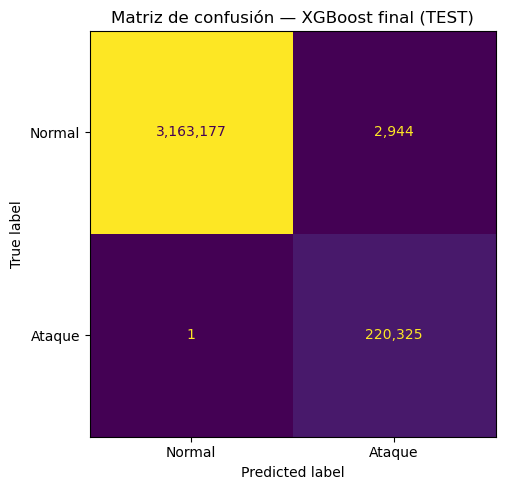

In [81]:
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=["Normal", "Ataque"])
disp.plot(ax=ax, values_format=",d", colorbar=False)
ax.set_title("Matriz de confusión — XGBoost final (TEST)")
plt.tight_layout()
plt.savefig(XGB_BINARY_RESULTS_PATH / "xgb_test_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

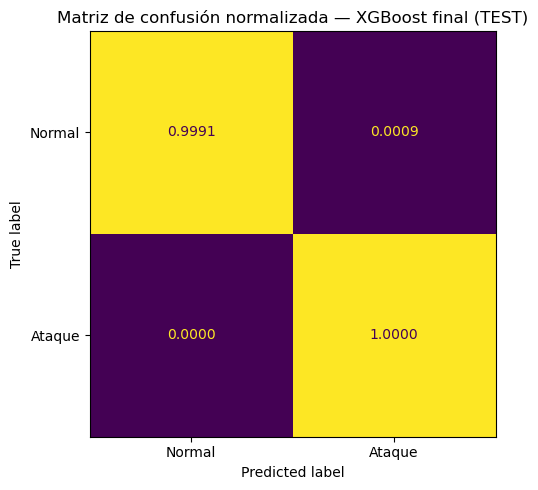

In [83]:
cm_test_normalized = confusion_matrix(y_test_bin, y_pred_test_xgb, labels=[0, 1], normalize="true")
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=(cm_test_normalized), display_labels=["Normal", "Ataque"])
disp.plot(ax=ax, values_format=".4f", colorbar=False)
ax.set_title("Matriz de confusión normalizada — XGBoost final (TEST)")
plt.tight_layout()
plt.savefig(XGB_BINARY_RESULTS_PATH / "xgb_test_confusion_matrix_normalized.png", dpi=300, bbox_inches="tight")
plt.show()

#### 3.5.3 Curva Precision–Recall

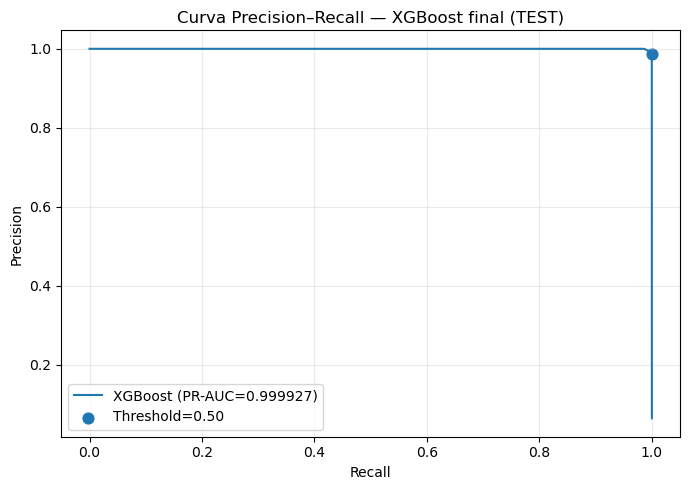

In [84]:
from sklearn.metrics import (precision_recall_curve, auc)
precision_curve_test, recall_curve_test, _ = (precision_recall_curve(y_test_bin, y_prob_test_xgb))
pr_auc_test = auc(recall_curve_test, precision_curve_test)
row_test = (df_test_final_metrics.iloc[0])
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_curve_test, precision_curve_test, label=(f"XGBoost " f"(PR-AUC={pr_auc_test:.6f})"))
ax.scatter(row_test["recall"], row_test["precision"], s=60, label=(f"Threshold={FINAL_XGB_THRESHOLD:.2f}"))
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision–Recall — XGBoost final (TEST)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(XGB_BINARY_RESULTS_PATH / "xgb_test_precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Interpretabilidad de XGBoost mediante SHAP

1. SHAP sobre las 49 características efectivamente utilizadas por el modelo.
2. Agrupación posterior de las contribuciones SHAP hacia las 22 variables originales.

In [90]:
import shap
print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [91]:
# Muestra representativa de TEST
from sklearn.model_selection import (StratifiedShuffleSplit)
SHAP_SAMPLE_SIZE = 20_000
shap_splitter = StratifiedShuffleSplit(n_splits=1, train_size=SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE)
shap_idx, _ = next(shap_splitter.split(np.zeros(len(y_test_bin)), y_test_bin))
X_test_shap = (X_test_bin_transformed[shap_idx])
y_test_shap = (np.asarray(y_test_bin)[shap_idx])
attack_t_shap = (attack_t_test[shap_idx])
print("Muestra SHAP:", X_test_shap.shape)
print("Prevalencia ataque:", f"{y_test_shap.mean():.4%}")

Muestra SHAP: (20000, 49)
Prevalencia ataque: 6.5050%


Calcular valores SHAP

In [92]:
explainer_xgb = shap.TreeExplainer(xgb_binary_tuned)

In [93]:
shap_values_xgb = (explainer_xgb.shap_values(X_test_shap))
shap_values_xgb = np.asarray(shap_values_xgb)

In [97]:
if shap_values_xgb.ndim == 3: 
    if (shap_values_xgb.shape[-1] == 2): shap_values_xgb = (shap_values_xgb[:, :, 1])
    else:
        raise ValueError("Formato SHAP no esperado: "f"{shap_values_xgb.shape}")
print("SHAP:", shap_values_xgb.shape)
assert (shap_values_xgb.shape[1] == len(xgb_binary_feature_names))

SHAP: (20000, 49)


En esta configuración SHAP explica normalmente la salida previa a la sigmoide del árbol. Por tanto:
- SHAP positivo → empuja la decisión hacia ataque.
- SHAP negativo → empuja hacia tráfico normal.
- magnitud absoluta alta → mayor influencia en la predicción.

### 4.1 Importancia global de las 49 características

In [99]:
mean_abs_shap = np.mean(np.abs(shap_values_xgb), axis=0)
mean_shap = np.mean(shap_values_xgb, axis=0)
df_shap_transformed = pd.DataFrame({"feature": xgb_binary_feature_names, "mean_abs_shap": mean_abs_shap, "mean_shap": mean_shap})
df_shap_transformed = (df_shap_transformed.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
display(df_shap_transformed.head(49).style.format({"mean_abs_shap": "{:.6f}", "mean_shap": "{:+.6f}"}))

,feature,mean_abs_shap,mean_shap
0,frequency__sp_freq,3.492180,-2.127114
1,frequency__dp_freq,2.741752,-2.678831
2,ip_features__sa_ip_freq,2.675160,-2.435552
3,ip_features__da_prefix_freq,1.775271,-0.377221
4,ip_features__sa_prefix_freq,1.656064,-1.276458
5,ip_features__da_ip_freq,1.478585,-0.579118
6,frequency__sas_freq,0.588354,-0.561221
7,onehot__exp_2,0.341630,-0.262571
8,onehot__exp_1,0.337182,-0.171701
9,onehot__pr_UDP,0.326571,-0.132324


In [100]:
SHAP_RESULTS_PATH = (XGB_BINARY_RESULTS_PATH / "shap")
SHAP_RESULTS_PATH.mkdir(parents=True, exist_ok=True)
df_shap_transformed.to_csv(SHAP_RESULTS_PATH / "shap_importance_transformed_features.csv", index=False)

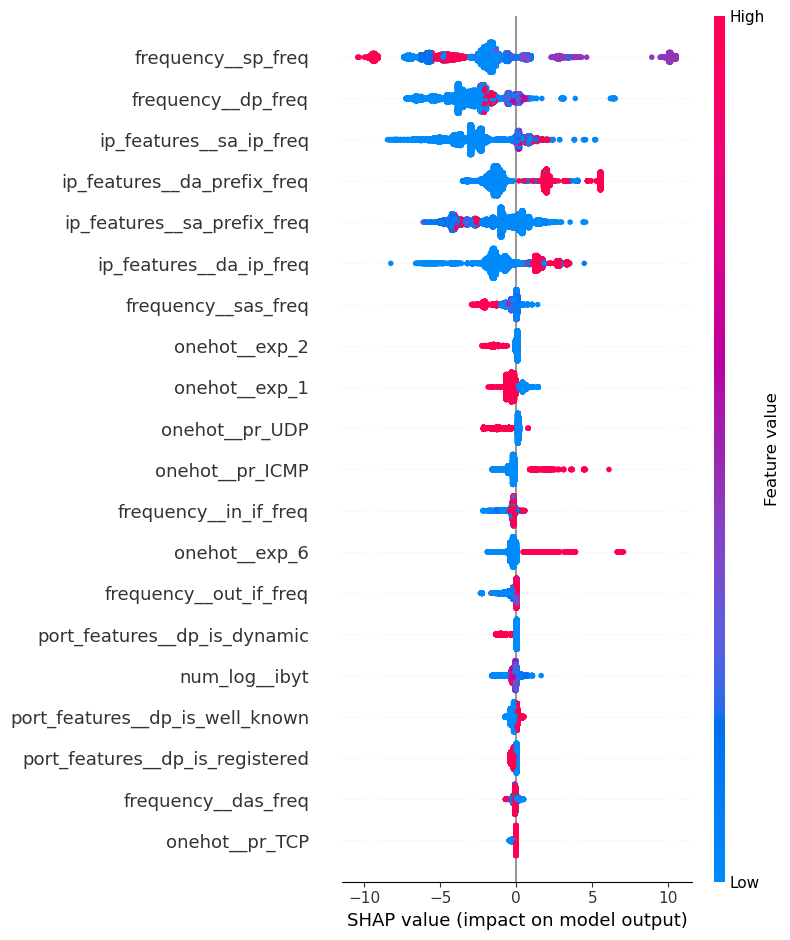

In [101]:
# SHAP Summary Plot
plt.figure()
shap.summary_plot(shap_values_xgb, X_test_shap, feature_names=(xgb_binary_feature_names), max_display=20, show=False)
plt.tight_layout()
plt.savefig(SHAP_RESULTS_PATH / "shap_summary_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()

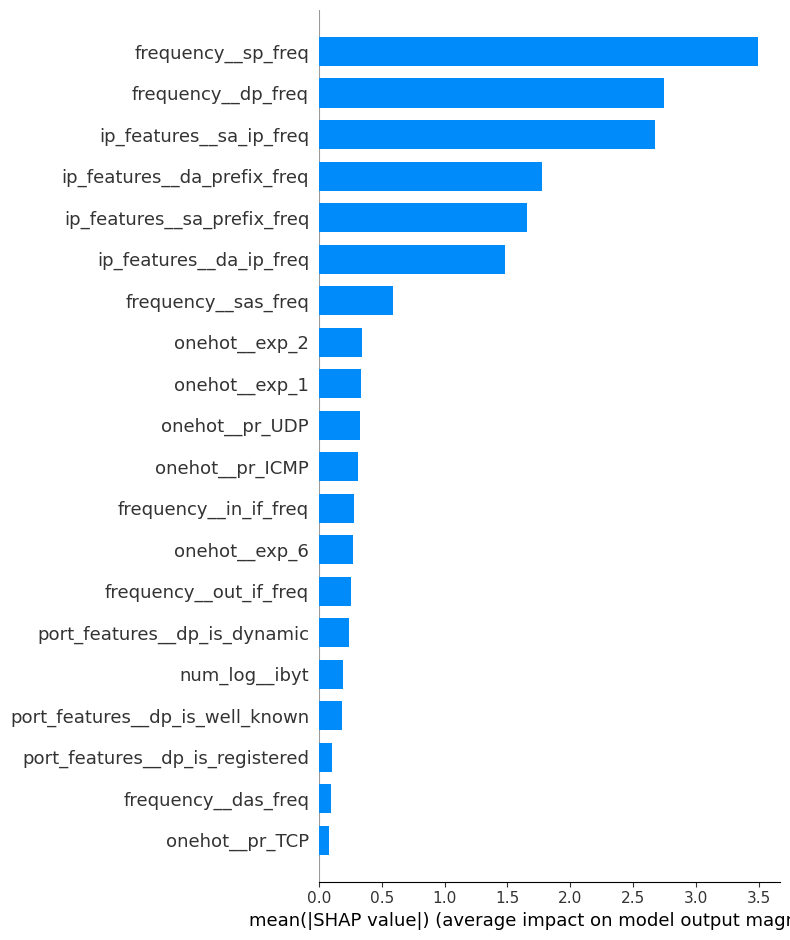

In [102]:
# Bar plot global SHAP
plt.figure()
shap.summary_plot(shap_values_xgb, X_test_shap, feature_names=(xgb_binary_feature_names), plot_type="bar", max_display=20, show=False)
plt.tight_layout()
plt.savefig(SHAP_RESULTS_PATH / "shap_global_bar_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.2 Agrupar SHAP hacia las 22 variables originales

In [104]:
def get_original_feature(transformed_name):
    name = str(transformed_name)
    if "__" in name: group, value = (name.split("__", 1))
    else: 
        group = ""
        value = name
    # Variables numéricas y flags
    if group in {"num_log", "flags"}:
        return value
    # One-hot
    if group == "onehot":
        if value.startswith("pr_"):
            return "pr"
        if value.startswith("exp_"):
            return "exp"
        return value
    # Frequency encoder
    if group == "frequency":
        if value.endswith("_freq"):
            return value[:-5]
        return value
    # Features derivadas de IP
    if group == "ip_features":
        if value.startswith("sa_"):
            return "sa"
        if value.startswith("da_"):
            return "da"
        return value
    # Indicadores de puertos
    if group == "port_features":
        if value.startswith("sp_"):
            return "sp"
        if value.startswith("dp_"):
            return "dp"
        return value
    return value

In [105]:
feature_group_map = pd.DataFrame({"transformed_feature": xgb_binary_feature_names,
    "original_feature": [get_original_feature(feature)
        for feature
        in xgb_binary_feature_names],
})
display(feature_group_map)

,transformed_feature,original_feature
0,num_log__td,td
1,num_log__ipkt,ipkt
2,num_log__ibyt,ibyt
3,flags__tcp_flag_fin,tcp_flag_fin
4,flags__tcp_flag_syn,tcp_flag_syn
5,flags__tcp_flag_rst,tcp_flag_rst
6,flags__tcp_flag_psh,tcp_flag_psh
7,flags__tcp_flag_ack,tcp_flag_ack
8,flags__tcp_flag_urg,tcp_flag_urg
9,flags__tcp_flag_ece,tcp_flag_ece


Primero sumamos, para cada registro, las contribuciones SHAP pertenecientes a la misma variable original. Después calculamos la magnitud media de esa contribución agrupada.

In [106]:
original_features = (predictor_columns)
grouped_shap_values = (np.zeros((shap_values_xgb.shape[0], len(original_features)), dtype=np.float32))
for idx_original, original_feature in enumerate(original_features):
    transformed_indices = [idx
        for idx, transformed_feature
        in enumerate(xgb_binary_feature_names)
        if (get_original_feature(transformed_feature) == original_feature)
    ]
    if len(transformed_indices) == 0:
        continue
    grouped_shap_values[:, idx_original] = (shap_values_xgb[:, transformed_indices].sum(axis=1))

Importancia de las 22 variables:

In [107]:
df_shap_original = pd.DataFrame({
    "feature": original_features,
    "mean_abs_shap": np.mean(np.abs(grouped_shap_values), axis=0),
    "mean_shap": np.mean(grouped_shap_values, axis=0),
})
df_shap_original = (df_shap_original.sort_values("mean_abs_shap", ascending=False,).reset_index(drop=True))
display(df_shap_original.style.format({"mean_abs_shap": "{:.6f}", "mean_shap": "{:+.6f}"}))

,feature,mean_abs_shap,mean_shap
0,sa,3.769778,-3.714340
1,sp,3.510379,-2.137289
2,da,3.222565,-0.956343
3,dp,3.182743,-3.114955
4,exp,0.783824,-0.633651
5,sas,0.588354,-0.561221
6,pr,0.516740,-0.447428
7,in_if,0.282269,-0.276329
8,out_if,0.254580,-0.237754
9,ibyt,0.195706,-0.115153


In [108]:
df_shap_original.to_csv(SHAP_RESULTS_PATH / "shap_importance_original_22_features.csv", index=False)

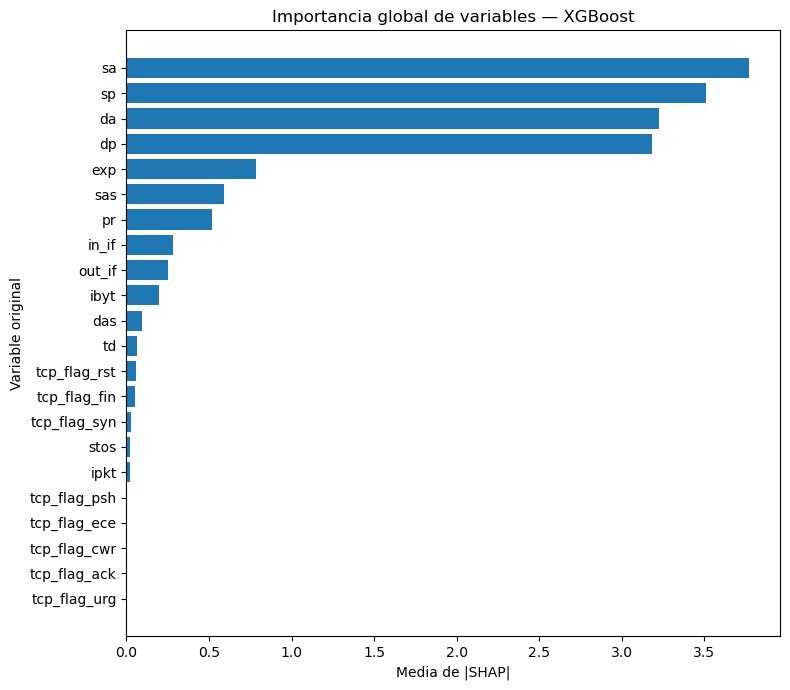

In [109]:
df_plot = (df_shap_original.sort_values("mean_abs_shap", ascending=True))
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(df_plot["feature"], df_plot["mean_abs_shap"])
ax.set_xlabel("Media de |SHAP|")
ax.set_ylabel("Variable original")
ax.set_title("Importancia global de variables — XGBoost")
plt.tight_layout()
plt.savefig(SHAP_RESULTS_PATH / "shap_original_features_bar.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.3 SHAP por tipo de ataque

In [110]:
SHAP_MAX_PER_ATTACK = 2_000
rng_shap = np.random.default_rng(RANDOM_STATE)
attack_specific_indices = []
y_test_np = np.asarray(y_test_bin)
for attack in ATTACK_CLASS_ORDER:
    indices = np.flatnonzero((y_test_np == 1) & (attack_t_test == attack))
    n_select = min(SHAP_MAX_PER_ATTACK, len(indices))
    selected = rng_shap.choice(indices, size=n_select, replace=False)
    attack_specific_indices.extend(selected.tolist())
attack_specific_indices = (np.asarray(attack_specific_indices, dtype=int))
print("Registros para SHAP por ataque:", f"{len(attack_specific_indices):,}")

Registros para SHAP por ataque: 11,922


In [111]:
X_shap_attacks = (X_test_bin_transformed[attack_specific_indices])
labels_shap_attacks = (attack_t_test[attack_specific_indices])

In [112]:
shap_values_attacks = (explainer_xgb.shap_values(X_shap_attacks))
shap_values_attacks = np.asarray(shap_values_attacks)
if shap_values_attacks.ndim == 3:
    shap_values_attacks = (shap_values_attacks[:, :, 1])

In [113]:
grouped_shap_attacks = np.zeros((shap_values_attacks.shape[0], len(original_features)), dtype=np.float32)
for idx_original, original_feature in enumerate(original_features):
    transformed_indices = [idx
        for idx, transformed_feature
        in enumerate(xgb_binary_feature_names)
        if (get_original_feature(transformed_feature) == original_feature)
    ]
    if transformed_indices:
        grouped_shap_attacks[:, idx_original] = (shap_values_attacks[:, transformed_indices].sum(axis=1))

In [114]:
# Tabla por ataque
rows_attack_shap = []
for attack in ATTACK_CLASS_ORDER:
    attack_mask = (labels_shap_attacks == attack)
    importance = np.mean(np.abs(grouped_shap_attacks[attack_mask]), axis=0)
    for feature, value in zip(original_features, importance):
        rows_attack_shap.append({"attack_t": attack, "feature": feature, "mean_abs_shap": value})
df_shap_by_attack = pd.DataFrame(rows_attack_shap)

In [115]:
top5_shap_by_attack = (df_shap_by_attack.sort_values(["attack_t", "mean_abs_shap"],ascending=[True, False]).groupby("attack_t", observed=True).head(5).reset_index(drop=True))
display(top5_shap_by_attack.style.format({"mean_abs_shap": "{:.6f}"}))

,attack_t,feature,mean_abs_shap
0,http_f,sa,2.083802
1,http_f,sp,0.805661
2,http_f,dp,0.794891
3,http_f,da,0.642600
4,http_f,sas,0.460973
5,icmp_f,sa,5.912241
6,icmp_f,pr,3.466921
7,icmp_f,da,2.084551
8,icmp_f,ibyt,0.594115
9,icmp_f,exp,0.356515


In [116]:
df_shap_by_attack.to_csv(SHAP_RESULTS_PATH / "shap_importance_by_attack.csv",index=False)
top5_shap_by_attack.to_csv(SHAP_RESULTS_PATH / "shap_top5_features_by_attack.csv", index=False)

**Heatmap de importancia relativa por ataque**

In [117]:
shap_attack_matrix = (df_shap_by_attack.pivot(index="attack_t", columns="feature", values="mean_abs_shap",).loc[ATTACK_CLASS_ORDER])

In [118]:
shap_attack_relative = (shap_attack_matrix.div(shap_attack_matrix.sum(axis=1), axis=0))

In [119]:
TOP_N_HEATMAP = 12
top_global_features = (df_shap_original.head(TOP_N_HEATMAP)["feature"].tolist())
heatmap_data = (shap_attack_relative[top_global_features])

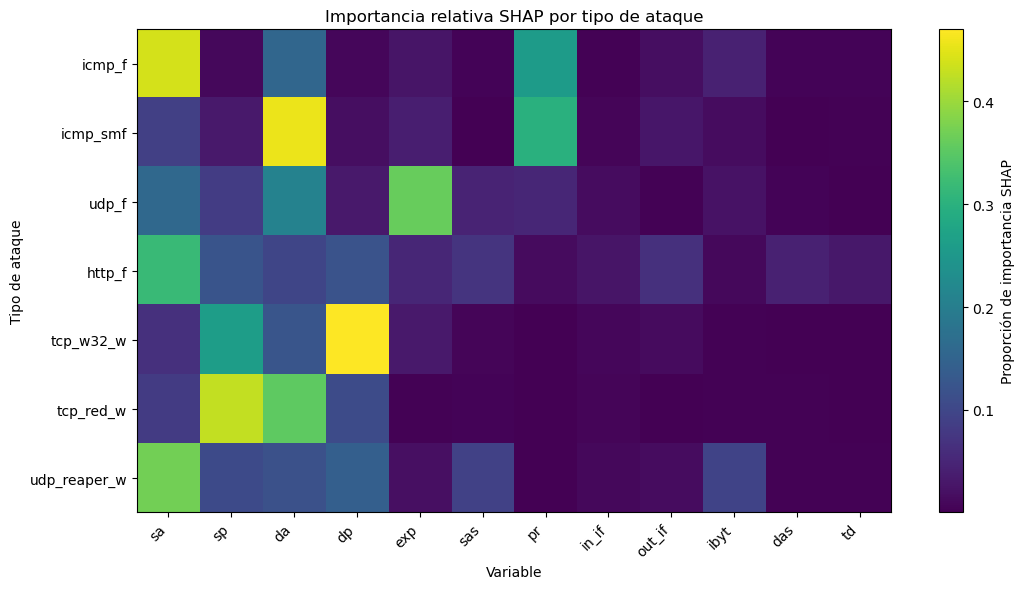

In [120]:
fig, ax = plt.subplots(figsize=(11, 6))
image = ax.imshow(heatmap_data.to_numpy(), aspect="auto")
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel("Variable")
ax.set_ylabel("Tipo de ataque")
ax.set_title("Importancia relativa SHAP por tipo de ataque")
fig.colorbar(image, ax=ax, label="Proporción de importancia SHAP")
plt.tight_layout()
plt.savefig(SHAP_RESULTS_PATH / "shap_heatmap_by_attack.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.4 Explicaciones locales de errores y casos representativos

In [121]:
y_test_np = np.asarray(y_test_bin)
fp_indices = np.flatnonzero((y_test_np == 0) & (y_pred_test_xgb == 1))
fn_indices = np.flatnonzero((y_test_np == 1) & (y_pred_test_xgb == 0))
tp_indices = np.flatnonzero((y_test_np == 1) & (y_pred_test_xgb == 1))
print("FP:", len(fp_indices))
print("FN:", len(fn_indices))
print("TP:", len(tp_indices))

FP: 2944
FN: 1
TP: 220325


In [122]:
local_cases = {}
# Falso positivo con mayor score
if len(fp_indices) > 0:
    idx_fp = fp_indices[np.argmax(y_prob_test_xgb[fp_indices])]
    local_cases["false_positive_high_confidence"] = idx_fp
# Falso negativo con mayor probabilidad (si llegara a existir)
if len(fn_indices) > 0:
    idx_fn = fn_indices[np.argmax(y_prob_test_xgb[fn_indices])]
    local_cases["false_negative_closest_to_threshold"] = idx_fn
# TP más cercano al threshold
if len(tp_indices) > 0:
    idx_tp_borderline = tp_indices[np.argmin(y_prob_test_xgb[tp_indices])]
    local_cases["true_positive_borderline"] = idx_tp_borderline
local_cases

{'false_positive_high_confidence': 1138995,
 'false_negative_closest_to_threshold': 2514473,
 'true_positive_borderline': 2752924}

Después podremos generar waterfalls SHAP para esos registros. No lo ejecutaría antes de conocer cuántos FP/FN tiene TEST.

sobre test - graficas, variables importantes SHAP